# Pipeline final (limpio)

Este notebook reemplaza el bloque de ensayo/error con un pipeline reproducible y exportable a LaTeX.

- Mantiene las 2 primeras celdas (entrenamiento) solo como referencia.
- Todo lo posterior es **inferencia + evaluación + simulación de caída**.


In [34]:
# --- CELDA MAESTRA: INICIALIZACIÓN COMPLETA (ARQUITECTURA SMALL U-NET) ---
import os
import json
import time
import hashlib
import glob
from dataclasses import dataclass, field
from datetime import datetime

import numpy as np
import pandas as pd
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.spatial import ConvexHull

# 1. REPRODUCIBILIDAD Y DISPOSITIVO (DET. + CUDA)
SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🖥️ DEVICE: {DEVICE}")


# --- CELDA MAESTRA: CONFIGURACIÓN DEFINITIVA (CON ALIAS LEGACY) ---
@dataclass
class RunConfig:
    # --- Rutas Base ---
    data_dir: str = "./dataset/training_collages"
    model_path: str = "unet_multiclass.pth"

    # --- Rutas del Ensemble (NUEVO FLUJO) ---
    ensemble_json_dir: str = "./temp_objs"
    ensemble_img_dir: str = "./ensemble_renders"

    # patrones de nombres para el ensemble
    ensemble_gt_pattern: str = "run_{i}_inbounds.json"
    ensemble_img_pattern: str = "run_{i}.png"

    # --- ALIAS DE COMPATIBILIDAD (Para que no fallen celdas viejas) ---
    collage_4000_path: str = "./ensemble_renders/run_0.png"
    json_4000_path: str = "./temp_objs/run_0_inbounds.json"

    # --- Búsqueda de mallas ---
    mesh_search_paths: tuple = (
        "./sand_atlas_meshes/1551_original_grains",
        "./sand_atlas_meshes/50000_generated_grains",
        "./dataset/meshes",
        "."
    )

    # --- Parámetros Físicos ---
    container_width_mm: float = 50.0
    num_runs: int = 5

    # --- Parámetros de Calibración ---
    interior_thr: float = 0.5
    tau_border: float = 0.40
    min_area_px: float = 10.0

    full_res: int = 8192
    calib_res: int = 4096


# Instanciar
cfg = RunConfig()

# Verificaciones de seguridad
print(f"✅ Configuración cargada.")
if os.path.exists(cfg.json_4000_path):
    print(f"   Legacy JSON OK: {cfg.json_4000_path}")
else:
    print(f"❌ CUIDADO: No encuentro {cfg.json_4000_path}")

# Crear carpetas de salida
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S_ENSEMBLE")
OUT_DIR = os.path.join("./outputs", f"run_{RUN_ID}")
os.makedirs(OUT_DIR, exist_ok=True)
print(f"📁 OUT_DIR: {OUT_DIR}")


# 3. DEFINICIÓN DE ARQUITECTURA (SMALL U-NET / BASE 32)
# Esta arquitectura coincide con los keys 'inc.net...', 'down1.1.net...' y tamaños de tu .pth
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Importante: Nombre 'net' para coincidir con el state_dict guardado
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNetMulticlass(nn.Module):
    def __init__(self, n_channels=3, n_classes=3):
        super().__init__()
        # ARQUITECTURA "SMALL" (Base 32, 4 Niveles)

        # Nivel 1 (Inc): 3 -> 32
        self.inc = DoubleConv(n_channels, 32)

        # Nivel 2 (Down1): 32 -> 64
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))

        # Nivel 3 (Down2): 64 -> 128
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))

        # Nivel 4 (Down3 - Bottleneck): 128 -> 256
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))

        # Upsampling
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)  # 128+128=256 -> 128

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)   # 64+64=128 -> 64

        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv3 = DoubleConv(64, 32)    # 32+32=64 -> 32

        # Salida: 32 -> n_classes
        self.outc = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)  # Bottleneck

        # Decoder
        x = self.up1(x4)
        if x.shape[2:] != x3.shape[2:]:
            x = F.interpolate(x, size=x3.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, x3], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        if x.shape[2:] != x2.shape[2:]:
            x = F.interpolate(x, size=x2.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up3(x)
        if x.shape[2:] != x1.shape[2:]:
            x = F.interpolate(x, size=x1.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, x1], dim=1)
        x = self.conv3(x)

        return self.outc(x)


# 4. FUNCIONES AUXILIARES Y CARGA
def sha256_file(filepath: str) -> str:
    if not os.path.exists(filepath):
        return "FILE_NOT_FOUND"
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            h.update(chunk)
    return h.hexdigest()


def load_model(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ No encuentro el modelo en: {path}")

    model = UNetMulticlass(n_classes=3)

    # Evita warning y es más seguro (fallback si tu torch no soporta weights_only)
    try:
        checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        checkpoint = torch.load(path, map_location=DEVICE)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    else:
        model.load_state_dict(checkpoint, strict=True)

    model.to(DEVICE)
    model.eval()
    return model


def evaluate_segmentation(model, data_dir: str, n_images: int = 50, batch_size: int = 4):
    if not os.path.exists(data_dir):
        print(f"⚠️ No encuentro {data_dir}. Saltando IoU.")
        return {"iou": [0, 0, 0], "mean_iou": 0}

    class SimpleSegDataset(torch.utils.data.Dataset):
        def __init__(self, root):
            self.files = sorted(glob.glob(os.path.join(root, "*.jpg")) + glob.glob(os.path.join(root, "*.png")))
            self.pairs = []
            for img_p in self.files:
                if "_mask" in img_p:
                    continue
                base = os.path.splitext(img_p)[0]
                mask_p = base + "_mask.png"
                if os.path.exists(mask_p):
                    self.pairs.append((img_p, mask_p))
            if n_images < len(self.pairs):
                self.pairs = self.pairs[:n_images]

        def __len__(self):
            return len(self.pairs)

        def __getitem__(self, i):
            img = cv2.imread(self.pairs[i][0])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            mask = cv2.imread(self.pairs[i][1], cv2.IMREAD_GRAYSCALE)

            # Mapear máscara a clases 0/1/2 (robusto)
            vals = np.unique(mask)
            if set(vals.tolist()).issubset({0, 127, 255}):
                m = np.zeros_like(mask, dtype=np.uint8)
                m[mask == 127] = 1
                m[mask == 255] = 2
                mask = m
            elif mask.max() > 2:
                mask = np.round((mask.astype(np.float32) / 255.0) * 2.0).astype(np.uint8)

            return transforms.ToTensor()(img), torch.from_numpy(mask).long()

    ds = SimpleSegDataset(data_dir)
    if len(ds) == 0:
        return {"iou": [0, 0, 0], "mean_iou": 0}

    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)
    intersection = np.zeros(3, dtype=np.float64)
    union = np.zeros(3, dtype=np.float64)

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = torch.argmax(model(imgs), dim=1)
            for cls in range(3):
                pred_inds = (preds == cls)
                target_inds = (masks == cls)
                intersection[cls] += (pred_inds & target_inds).sum().item()
                union[cls] += (pred_inds | target_inds).sum().item()

    iou = intersection / (union + 1e-6)
    return {"classes": ["Fondo", "Arena", "Borde"], "iou": iou.tolist(), "mean_iou": float(iou.mean())}


# 5. EJECUCIÓN: CARGAR EL MODELO AHORA
print("⏳ Cargando modelo...")
if os.path.exists(cfg.model_path):
    try:
        model = load_model(cfg.model_path)
        print(f"✅ ¡Modelo cargado y listo! (Hash: {sha256_file(cfg.model_path)[:8]})")
    except Exception as e:
        print(f"❌ Error cargando modelo: {e}")
        model = None
else:
    print(f"⚠️ ALERTA: No existe el archivo {cfg.model_path}. Asegúrate de tenerlo.")


# --- SLIDING-WINDOW CON SOLAPE + BLENDING (CACHE PROBS) ---
def _hann2d(ts: int) -> np.ndarray:
    w = np.hanning(ts).astype(np.float32)
    w2d = np.outer(w, w)
    return np.clip(w2d, 1e-6, None)


def _tile_to_tensor(tile_bgr: np.ndarray, device, bgr_to_rgb: bool = True, mean=None, std=None) -> torch.Tensor:
    # Nota: este preproceso asume que el entrenamiento usó RGB y normalización /255
    if bgr_to_rgb:
        tile = cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB)
    else:
        tile = tile_bgr

    x = tile.astype(np.float32) / 255.0  # [H,W,3]
    x = x.transpose(2, 0, 1)             # [3,H,W]

    if mean is not None and std is not None:
        mean = np.asarray(mean, dtype=np.float32)[:, None, None]
        std = np.asarray(std, dtype=np.float32)[:, None, None]
        x = (x - mean) / std

    return torch.from_numpy(x).unsqueeze(0).to(device)  # [1,3,H,W]


def predict_sliding_window_probs_overlap(model, image_bgr, tile_size: int = 512, overlap: float = 0.5,
                                         bgr_to_rgb: bool = True, mean=None, std=None):
    """
    Devuelve probs[clase, H, W] para imagen grande usando solape + blending (Hann).
    """
    model.eval()
    h, w = image_bgr.shape[:2]
    stride = max(1, int(tile_size * (1.0 - overlap)))

    pad_h = (tile_size - h % tile_size) % tile_size
    pad_w = (tile_size - w % tile_size) % tile_size
    img_pad = cv2.copyMakeBorder(image_bgr, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
    hp, wp = img_pad.shape[:2]

    # posiciones que aseguren cobertura completa
    ys = list(range(0, max(hp - tile_size + 1, 1), stride))
    xs = list(range(0, max(wp - tile_size + 1, 1), stride))
    if ys[-1] != hp - tile_size:
        ys.append(hp - tile_size)
    if xs[-1] != wp - tile_size:
        xs.append(wp - tile_size)

    w2d = _hann2d(tile_size)  # [ts,ts]
    prob_acc = np.zeros((3, hp, wp), dtype=np.float32)
    w_acc = np.zeros((hp, wp), dtype=np.float32)

    with torch.no_grad():
        for y in ys:
            for x in xs:
                tile = img_pad[y:y + tile_size, x:x + tile_size]
                t = _tile_to_tensor(tile, DEVICE, bgr_to_rgb=bgr_to_rgb, mean=mean, std=std)
                logits = model(t)
                p = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()  # [3,ts,ts]

                prob_acc[:, y:y + tile_size, x:x + tile_size] += p * w2d[None, :, :]
                w_acc[y:y + tile_size, x:x + tile_size] += w2d

    prob_acc /= np.clip(w_acc[None, :, :], 1e-6, None)
    return prob_acc[:, :h, :w]



🖥️ DEVICE: cuda:0
✅ Configuración cargada.
   Legacy JSON OK: ./temp_objs/run_0_inbounds.json
📁 OUT_DIR: ./outputs\run_20260127_031124_ENSEMBLE
⏳ Cargando modelo...
✅ ¡Modelo cargado y listo! (Hash: 1d13e45d)


In [35]:
# --- 2) MÉTRICAS DE SEGMENTACIÓN (IoU / Dice) 3-CLASES y EXPORT A LATEX ---
import os
import glob
import numpy as np
import cv2 as cv
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# =========================
# Utils
# =========================
def _swap_ext_to_png(path: str) -> str:
    base = os.path.splitext(os.path.basename(path))[0]
    return base + ".png"

def _read_gray(path: str):
    return cv.imread(path, cv.IMREAD_GRAYSCALE)

def _read_bgr(path: str):
    return cv.imread(path, cv.IMREAD_COLOR)

def _det_crop(img: np.ndarray, cs: int, seed: int):
    """
    Crop determinista pseudo-aleatorio: evita que el centro sea sistemáticamente 'vacío'
    y mantiene reproducibilidad.
    """
    h, w = img.shape[:2]
    if h <= cs or w <= cs:
        # fallback: resize (más cercano al entrenamiento cuando no alcanza tamaño)
        if img.ndim == 2:
            return cv.resize(img, (cs, cs), interpolation=cv.INTER_NEAREST)
        return cv.resize(img, (cs, cs), interpolation=cv.INTER_LINEAR)

    rng = np.random.RandomState(seed)
    y0 = rng.randint(0, h - cs + 1)
    x0 = rng.randint(0, w - cs + 1)
    return img[y0:y0+cs, x0:x0+cs]

# =========================
# Dataset 3-clases (GT desde masks + instances)
# =========================
class SegDataset3C(Dataset):
    """
    GT consistente con U-Net.ipynb:
      - masks/: binario (arena vs fondo) -> clase 1
      - instances/: instancias -> bordes por MORPH_GRADIENT -> clase 2
      - prioridad: borde (2) sobre interior (1)
    """
    def __init__(self, data_dir: str, crop_size: int = 512, border_kernel: int = 5, seed: int = 123):
        self.images_dir = os.path.join(data_dir, "images")
        self.masks_dir  = os.path.join(data_dir, "masks")
        self.inst_dir   = os.path.join(data_dir, "instances")
        self.crop_size  = int(crop_size)
        self.seed       = int(seed)

        self.images = []
        for ext in ("*.png","*.jpg","*.jpeg","*.tif","*.tiff"):
            self.images += glob.glob(os.path.join(self.images_dir, ext))
        self.images = sorted(self.images)

        if len(self.images) == 0:
            raise RuntimeError(f"Dataset vacío: no hay imágenes en {self.images_dir}")
        if not os.path.isdir(self.masks_dir):
            raise RuntimeError(f"No existe masks/: {self.masks_dir}")
        if not os.path.isdir(self.inst_dir):
            raise RuntimeError(f"No existe instances/: {self.inst_dir}")

        k = int(border_kernel)
        if k < 3: k = 3
        if k % 2 == 0: k += 1
        self.kernel = np.ones((k, k), np.uint8)

    def __len__(self):
        return len(self.images)

    def _get_paths(self, img_path: str):
        base_png = _swap_ext_to_png(img_path)
        mask_path = os.path.join(self.masks_dir, base_png)
        inst_path = os.path.join(self.inst_dir, base_png)
        return mask_path, inst_path

    def _get_borders(self, inst_mask: np.ndarray) -> np.ndarray:
        inst_u8 = inst_mask.astype(np.uint8, copy=False)
        grad = cv.morphologyEx(inst_u8, cv.MORPH_GRADIENT, self.kernel)
        borders = np.zeros_like(inst_u8, dtype=np.uint8)
        borders[grad > 0] = 1
        return borders

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path, inst_path = self._get_paths(img_path)

        img  = _read_bgr(img_path)
        mask = _read_gray(mask_path)
        inst = _read_gray(inst_path)

        if img is None:
            raise RuntimeError(f"No pude leer imagen: {img_path}")
        if mask is None:
            raise RuntimeError(f"No pude leer mask: {mask_path}")
        if inst is None:
            raise RuntimeError(f"No pude leer instances: {inst_path}")

        cs = self.crop_size
        # crop determinista por idx
        img  = _det_crop(img,  cs, seed=self.seed + idx)
        mask = _det_crop(mask, cs, seed=self.seed + idx)
        inst = _det_crop(inst, cs, seed=self.seed + idx)

        border = self._get_borders(inst)                  # {0,1}
        final_mask = np.zeros_like(mask, dtype=np.int64)  # 0 fondo
        final_mask[mask > 0] = 1                          # interior
        final_mask[border > 0] = 2                        # borde sobreescribe

        # Importante: mantener BGR (en U-Net.ipynb NO convertiste a RGB)
        img_t = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0
        msk_t = torch.from_numpy(final_mask).long()
        return img_t, msk_t

# =========================
# Métricas IoU / Dice
# =========================
def compute_iou_dice_from_confmat(C: np.ndarray, eps: float = 1e-6):
    num_classes = C.shape[0]
    ious, dices = [], []
    for k in range(num_classes):
        TP = C[k,k]
        FP = C[:,k].sum() - TP
        FN = C[k,:].sum() - TP
        den_iou  = (TP + FP + FN)
        den_dice = (2*TP + FP + FN)
        iou  = (TP / (den_iou + eps))  if den_iou  > 0 else np.nan
        dice = (2*TP / (den_dice + eps)) if den_dice > 0 else np.nan
        ious.append(float(iou) if np.isfinite(iou) else float("nan"))
        dices.append(float(dice) if np.isfinite(dice) else float("nan"))
    return ious, dices

def evaluate_segmentation_3c(model, data_dir, n_images=200, batch_size=8, crop_size=512, border_kernel=5, seed=123):
    model.eval()
    ds = SegDataset3C(data_dir, crop_size=crop_size, border_kernel=border_kernel, seed=seed)
    n_use = min(int(n_images), len(ds))
    idxs = list(range(n_use))
    loader = DataLoader(torch.utils.data.Subset(ds, idxs),
                        batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=False)

    num_classes = 3
    C = np.zeros((num_classes, num_classes), dtype=np.int64)

    # Diagnóstico GT (fracciones)
    frac_bg = frac_in = frac_bd = 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="📊 Evaluando segmentación"):
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            y_true = masks.numpy().reshape(-1)
            y_pred = preds.reshape(-1)

            # fracciones GT acumuladas
            frac_bg += float((y_true == 0).mean())
            frac_in += float((y_true == 1).mean())
            frac_bd += float((y_true == 2).mean())

            valid = (y_true >= 0) & (y_true < num_classes)
            bc = np.bincount(num_classes*y_true[valid] + y_pred[valid], minlength=num_classes**2)
            C += bc.reshape(num_classes, num_classes)

    frac_bg /= max(1, len(loader))
    frac_in /= max(1, len(loader))
    frac_bd /= max(1, len(loader))
    print(f"🧪 Fracción promedio de píxeles GT: fondo={frac_bg:.6f} | arena={frac_in:.6f} | borde={frac_bd:.6f}")

    ious, dices = compute_iou_dice_from_confmat(C)
    miou  = float(np.nanmean(ious))
    mdice = float(np.nanmean(dices))

    result = {
        "classes": ["Fondo","Arena","Borde"],
        "iou": ious,
        "dice": dices,
        "miou": miou,
        "mdice": mdice,
        "n_images": int(n_use),
        "diag_gt_frac_bg": frac_bg,
        "diag_gt_frac_interior": frac_in,
        "diag_gt_frac_border": frac_bd,
    }
    return result

# Ejecutar evaluación
seg = evaluate_segmentation_3c(model, cfg.data_dir, n_images=200, batch_size=8, crop_size=512, border_kernel=5, seed=SEED)
print(seg)

# Export LaTeX
latex_seg = f"""\\begin{{table}}[htbp]
\\centering
\\caption{{Desempeño del Modelo de Segmentación (Set de Validación)}}
\\label{{tab:segmentation_metrics}}
\\begin{{tabular}}{{lcc}}
\\toprule
\\textbf{{Clase}} & \\textbf{{IoU (Jaccard)}} & \\textbf{{Dice (F1-Score)}} \\\\
\\midrule
Fondo (Background) & {seg['iou'][0]:.4f} & {seg['dice'][0]:.4f} \\\\
Arena (Interior)   & {seg['iou'][1]:.4f} & {seg['dice'][1]:.4f} \\\\
Borde (Interfase)  & {seg['iou'][2]:.4f} & {seg['dice'][2]:.4f} \\\\
\\midrule
\\textbf{{Promedio (mIoU)}} & \\textbf{{{seg['miou']:.4f}}} & \\textbf{{{seg['mdice']:.4f}}} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
tex_path = os.path.join(OUT_DIR, "table_segmentation_metrics.tex")
with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_seg)
print("✅ LaTeX guardado:", tex_path)


📊 Evaluando segmentación: 100%|██████████| 25/25 [03:32<00:00,  8.49s/it]

🧪 Fracción promedio de píxeles GT: fondo=0.812848 | arena=0.167934 | borde=0.019218
{'classes': ['Fondo', 'Arena', 'Borde'], 'iou': [0.9996961567690988, 0.9939342195011417, 0.9387554218058174], 'dice': [0.9998480553008653, 0.9969578833446292, 0.9684103639348497], 'miou': 0.9774619326920192, 'mdice': 0.9884054341934481, 'n_images': 200, 'diag_gt_frac_bg': 0.8128481101989746, 'diag_gt_frac_interior': 0.16793418884277345, 'diag_gt_frac_border': 0.019217700958251954}
✅ LaTeX guardado: ./outputs\run_20260127_031124_ENSEMBLE\table_segmentation_metrics.tex


In [36]:
# --- 3) INFERENCIA EN COLLAGE (SLIDING WINDOW) - CACHE PROBS (BLENDING + AMP OK) ---
import os
import numpy as np
import cv2
import torch

def _hann2d(ts: int) -> np.ndarray:
    w = np.hanning(ts).astype(np.float32)
    w2d = np.outer(w, w)
    return np.clip(w2d, 1e-6, None)

def predict_sliding_window_probs(model, image_bgr, tile_size=512, overlap=0.33,
                                 use_hann=True, amp=True):
    """
    Devuelve probs[clase, H, W] para imagen grande usando solape + blending.
    - Consistente con tu entrenamiento: entrada BGR, /255, sin normalización extra.
    """
    model.eval()
    H, W = image_bgr.shape[:2]
    ts = int(tile_size)

    # stride por solape
    stride = int(ts * (1.0 - float(overlap)))
    stride = max(1, stride)

    # posiciones (clamp) + asegurar último tile
    y_starts = list(range(0, max(H - ts + 1, 1), stride))
    x_starts = list(range(0, max(W - ts + 1, 1), stride))
    if len(y_starts) == 0: y_starts = [0]
    if len(x_starts) == 0: x_starts = [0]
    if y_starts[-1] != H - ts: y_starts.append(max(H - ts, 0))
    if x_starts[-1] != W - ts: x_starts.append(max(W - ts, 0))
    y_starts = sorted(set([int(y) for y in y_starts]))
    x_starts = sorted(set([int(x) for x in x_starts]))

    # acumuladores
    probs_acc = np.zeros((3, H, W), dtype=np.float32)
    w_acc     = np.zeros((H, W), dtype=np.float32)

    w_tile = _hann2d(ts) if use_hann and ts >= 8 else np.ones((ts, ts), dtype=np.float32)

    amp_enabled = (amp and (DEVICE.type == "cuda"))

    with torch.inference_mode():
        for y in y_starts:
            for x in x_starts:
                tile = image_bgr[y:y+ts, x:x+ts]
                if tile.shape[0] != ts or tile.shape[1] != ts:
                    # seguridad (por si H/W < tile_size)
                    tile = cv2.copyMakeBorder(
                        tile,
                        0, max(0, ts - tile.shape[0]),
                        0, max(0, ts - tile.shape[1]),
                        cv2.BORDER_REFLECT
                    )
                    tile = tile[:ts, :ts]

                t = torch.from_numpy(tile).permute(2, 0, 1).float().unsqueeze(0) / 255.0
                t = t.to(DEVICE, non_blocking=True)

                # AMP actualizado
                with torch.amp.autocast(device_type="cuda", enabled=amp_enabled):
                    logits = model(t)
                    p = torch.softmax(logits, dim=1).squeeze(0).float().cpu().numpy()  # [3,ts,ts]

                probs_acc[:, y:y+ts, x:x+ts] += p * w_tile[None, :, :]
                w_acc[y:y+ts, x:x+ts] += w_tile

    probs_acc /= np.clip(w_acc[None, :, :], 1e-6, None)
    return probs_acc

# --------- Cache probs (4000) ----------
img_4000 = cv2.imread(cfg.collage_4000_path, cv2.IMREAD_COLOR)
if img_4000 is None:
    raise FileNotFoundError(f"No pude leer {cfg.collage_4000_path}")

mm_per_px_4000 = float(cfg.container_width_mm) / float(img_4000.shape[1])
print(f"📏 mm_per_px (4000) = {mm_per_px_4000:.9f} mm/px")

PROBS_CACHE = os.path.join(OUT_DIR, "probs_4000.npy")

if os.path.exists(PROBS_CACHE):
    probs_4000 = np.load(PROBS_CACHE)
    # sanity shape
    assert probs_4000.ndim == 3 and probs_4000.shape[0] == 3, f"Cache inválido: {probs_4000.shape}"
    print(f"✅ Cache probs cargado: {PROBS_CACHE}")
else:
    print("🧠 Inferencia sliding-window (blending) ...")
    probs_4000 = predict_sliding_window_probs(model, img_4000, tile_size=512, overlap=0.33,
                                              use_hann=True, amp=True)
    np.save(PROBS_CACHE, probs_4000.astype(np.float32))
    print(f"✅ Cache probs guardado: {PROBS_CACHE}")



📏 mm_per_px (4000) = 0.006103516 mm/px
🧠 Inferencia sliding-window (blending) ...
✅ Cache probs guardado: ./outputs\run_20260127_031124_ENSEMBLE\probs_4000.npy


In [37]:
# ================================
# 4) GT acumulado desde run_i_inbounds.json (con filtro de capa superior)
# ================================
import os, json
import numpy as np

print(f"🚀 Calculando GT Acumulado de {cfg.num_runs} simulaciones...")

VISIBLE_FRAC = 0.45
USE_TOP_LAYER_FILTER = True

# Directorios candidatos para JSON (evita confundir metadata de render vs dataset vs inbounds)
JSON_DIR_CANDIDATES = []
# 1) el configurado
if getattr(cfg, "ensemble_json_dir", None):
    JSON_DIR_CANDIDATES.append(cfg.ensemble_json_dir)
# 2) otros comunes (ajusta si aplica)
for d in ("./temp_objs", "./ensemble_dataset"):
    if d not in JSON_DIR_CANDIDATES:
        JSON_DIR_CANDIDATES.append(d)

print("📁 JSON_DIR_CANDIDATES:")
for d in JSON_DIR_CANDIDATES:
    print(f"  - {d} | exists: {os.path.exists(d)}")

def _find_run_json(i: int) -> str:
    """
    Busca primero run_{i}_inbounds.json, luego run_{i}.json, en directorios candidatos.
    """
    for root in JSON_DIR_CANDIDATES:
        c1 = os.path.join(root, f"run_{i}_inbounds.json")
        if os.path.exists(c1):
            return c1
        c2 = os.path.join(root, f"run_{i}.json")
        if os.path.exists(c2):
            return c2
    return ""

def load_obj_vertices(obj_path: str) -> np.ndarray:
    verts = []
    with open(obj_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("v "):
                parts = line.strip().split()
                if len(parts) >= 4:
                    verts.append([float(parts[1]), float(parts[2]), float(parts[3])])
    return np.asarray(verts, dtype=float)

def resolve_mesh_path(mesh_path: str, json_dir: str = None) -> str:
    """
    Resuelve mesh_path buscando:
      0) path tal cual
      1) relativo al directorio del JSON actual
      2) relativo a cfg.ensemble_json_dir
      3) búsqueda en cfg.mesh_search_paths (por path completo y por basename)
    """
    if not mesh_path:
        return ""
    mp = mesh_path.replace("\\", "/").strip()

    # 0) tal cual
    cand0 = os.path.normpath(mp)
    if os.path.exists(cand0):
        return cand0

    # 1) relativo al JSON actual
    if json_dir:
        candj = os.path.normpath(os.path.join(json_dir, mp))
        if os.path.exists(candj):
            return candj

    # 2) relativo a ensemble_json_dir
    cand1 = os.path.normpath(os.path.join(cfg.ensemble_json_dir, mp))
    if os.path.exists(cand1):
        return cand1

    # 3) búsqueda en rutas conocidas
    bn = os.path.basename(mp)
    for root in getattr(cfg, "mesh_search_paths", (".",)):
        c2 = os.path.normpath(os.path.join(root, mp))
        if os.path.exists(c2):
            return c2
        c3 = os.path.normpath(os.path.join(root, bn))
        if os.path.exists(c3):
            return c3

    return ""

# Cache d_raw por obj
_OBJ_DEQ_CACHE = {}

def eq_diameter_from_obj_xy_units(obj_path: str) -> float:
    """
    Diámetro equivalente por área de convex hull en XY, en unidades del OBJ.
    """
    if obj_path in _OBJ_DEQ_CACHE:
        return _OBJ_DEQ_CACHE[obj_path]

    import cv2
    verts = load_obj_vertices(obj_path)
    if verts.size == 0:
        _OBJ_DEQ_CACHE[obj_path] = np.nan
        return np.nan

    xy = verts[:, :2]
    pts = xy.astype(np.float32).reshape(-1, 1, 2)
    hull = cv2.convexHull(pts)
    area = float(cv2.contourArea(hull))
    if area <= 0:
        _OBJ_DEQ_CACHE[obj_path] = np.nan
        return np.nan

    d_raw = float(2.0 * np.sqrt(area / np.pi))
    _OBJ_DEQ_CACHE[obj_path] = d_raw
    return d_raw

def _get_scale_mm(it: dict) -> float:
    """
    scale puede venir como float o vector. Tomamos un escalar robusto.
    """
    sc = it.get("scale", it.get("meshScale", it.get("mesh_scale", 1.0)))
    if isinstance(sc, (list, tuple)) and len(sc) > 0:
        sc = sc[0]
    try:
        return float(sc)
    except Exception:
        return 1.0

def compute_item_d_mm(it: dict, json_dir: str = None) -> float:
    """
    d_mm = d_raw_obj_units * scale
    scale viene del JSON (PyBullet meshScale) y se asume que convierte OBJ -> mm.
    """
    if "_dmm" in it and np.isfinite(it["_dmm"]):
        return float(it["_dmm"])

    mesh_path = it.get("mesh_path", None)
    if not mesh_path:
        it["_dmm"] = np.nan
        return np.nan

    obj_path = resolve_mesh_path(mesh_path, json_dir=json_dir)
    if not obj_path or not os.path.exists(obj_path):
        it["_dmm"] = np.nan
        return np.nan

    d_raw = eq_diameter_from_obj_xy_units(obj_path)
    if not np.isfinite(d_raw):
        it["_dmm"] = np.nan
        return np.nan

    sc = _get_scale_mm(it)
    dmm = float(d_raw * sc)
    it["_dmm"] = dmm
    return dmm

def select_top_layer_items(items: list, visible_frac: float = 0.45, json_dir: str = None) -> list:
    """
    Filtra quedándose con la fracción superior.
    Intenta usar z_top = z_center + 0.5*d_mm. Si d_mm no es confiable, cae a z_center.
    """
    if not items:
        return items

    zc_list = []
    ztop_list = []
    ok_d = 0

    for it in items:
        pos = it.get("position", None)
        if not (isinstance(pos, (list, tuple)) and len(pos) >= 3):
            continue
        try:
            zc = float(pos[2])
        except Exception:
            continue

        dmm = compute_item_d_mm(it, json_dir=json_dir)
        if np.isfinite(dmm) and dmm > 0:
            ok_d += 1
            ztop = zc + 0.5 * dmm
        else:
            ztop = np.nan

        zc_list.append(zc)
        ztop_list.append(ztop)

    if len(zc_list) < 10:
        return items

    zc_arr = np.asarray(zc_list, dtype=float)
    zt_arr = np.asarray(ztop_list, dtype=float)

    # Usar z_top solo si hay suficiente cobertura de d_mm
    frac_ok = ok_d / max(1, len(zc_arr))
    use_ztop = (frac_ok >= 0.80) and np.isfinite(zt_arr).any()

    zref = zt_arr if use_ztop else zc_arr
    zref = zref[np.isfinite(zref)]
    if zref.size < 10:
        return items

    q = 1.0 - float(visible_frac)
    q = min(max(q, 0.0), 1.0)
    z_thr = float(np.quantile(zref, q))

    out = []
    for it in items:
        pos = it.get("position", None)
        if not (isinstance(pos, (list, tuple)) and len(pos) >= 3):
            continue
        zc = float(pos[2])

        if use_ztop:
            dmm = compute_item_d_mm(it, json_dir=json_dir)
            zval = zc + 0.5*dmm if (np.isfinite(dmm) and dmm > 0) else zc
        else:
            zval = zc

        if np.isfinite(zval) and zval >= z_thr:
            out.append(it)

    return out

def compute_gt_diameters_mm(items: list, json_dir: str = None) -> list:
    diams = []
    for it in items:
        dmm = compute_item_d_mm(it, json_dir=json_dir)
        if np.isfinite(dmm) and dmm > 0:
            diams.append(float(dmm))
    return diams

# ---------- Loop por runs ----------
gt_all = []
gt_by_run = []

for i in range(cfg.num_runs):
    current_json_path = _find_run_json(i)
    if not current_json_path:
        print(f"⚠️ Run {i}: no encuentro JSON.")
        continue

    json_dir = os.path.dirname(current_json_path)

    with open(current_json_path, "r", encoding="utf-8") as f:
        items = json.load(f)

    n_before = len(items)

    if USE_TOP_LAYER_FILTER:
        items = select_top_layer_items(items, visible_frac=VISIBLE_FRAC, json_dir=json_dir)

    n_after = len(items)
    diams = compute_gt_diameters_mm(items, json_dir=json_dir)

    if len(diams) == 0:
        print(f"⚠️ Run {i}: sin diámetros (revisa mesh_path / mesh_search_paths / escala).")
        continue

    gt_by_run.append({"run": i, "n": len(diams), "n_before": n_before, "n_after": n_after})
    gt_all.extend(diams)
    print(f"✅ Run {i}: n={len(diams)} | before={n_before} -> after={n_after} | json={os.path.basename(current_json_path)}")

gt_all = np.asarray(gt_all, dtype=float)
if gt_all.size == 0:
    raise RuntimeError("No se pudo calcular GT (gt_all vacío). Revisa rutas OBJ y cfg.mesh_search_paths.")

D10_GT, D50_GT, D90_GT = np.percentile(gt_all, [10, 50, 90])
print(f"📌 GT acumulado: D10={D10_GT:.4f} mm | D50={D50_GT:.4f} mm | D90={D90_GT:.4f} mm | n={gt_all.size}")

# Guardar resumen
gt_ensemble = {
    "n_total": int(gt_all.size),
    "use_top_layer_filter": bool(USE_TOP_LAYER_FILTER),
    "visible_frac": float(VISIBLE_FRAC),
    "runs": gt_by_run,
    "note": "d_mm = d_raw_obj_units * scale (scale desde JSON PyBullet, asumido OBJ->mm). Top-layer: quantile en z_top (fallback z_center).",
}
os.makedirs(OUT_DIR, exist_ok=True)
out_path = os.path.join(OUT_DIR, "gt_ensemble_toplayer.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(gt_ensemble, f, indent=2)
print(f"✅ GT guardado: {out_path}")


🚀 Calculando GT Acumulado de 5 simulaciones...
📁 JSON_DIR_CANDIDATES:
  - ./temp_objs | exists: True
  - ./ensemble_dataset | exists: True
✅ Run 0: n=1800 | before=3999 -> after=1800 | json=run_0_inbounds.json
✅ Run 1: n=1800 | before=4000 -> after=1800 | json=run_1_inbounds.json
✅ Run 2: n=1800 | before=4000 -> after=1800 | json=run_2_inbounds.json
✅ Run 3: n=1800 | before=4000 -> after=1800 | json=run_3_inbounds.json
✅ Run 4: n=1800 | before=3999 -> after=1800 | json=run_4_inbounds.json
📌 GT acumulado: D10=0.7904 mm | D50=1.1569 mm | D90=1.5120 mm | n=9000
✅ GT guardado: ./outputs\run_20260127_031124_ENSEMBLE\gt_ensemble_toplayer.json


In [38]:
# ================================
# 5) Auto-calibración (modo rápido) - ROBUSTO
# ================================
# Objetivo:
#  (1) Cargar calibration_grid_4000.csv (de una ejecución previa) si existe
#  (2) Obtener "best" y escalar parámetros a FULL (8K) de forma consistente
#  (3) Dejar meta_4000 listo para extracción/reporte

import os, glob, json
import numpy as np
import pandas as pd
import cv2

# ----------------
# Control
# ----------------
USE_CALIB_CACHE = True
CALIB_CACHE_DIR = None   # p.ej.: "./outputs/run_20260123_073431_ENSEMBLE"
MANUAL_BEST = None       # dict(...) si quieres fijarlo manualmente

# Umbral base anti-finos (para derivar min_area_px si usas min_area_factor)
min_d_base_mm = 0.063  # 0.063mm ~ límite inferior (ajustable)

# ----------------
# Helpers
# ----------------
def _find_latest_calib_csv(outputs_root: str = "./outputs",
                           filename: str = "calibration_grid_4000.csv"):
    cand = []
    for p in glob.glob(os.path.join(outputs_root, "**", filename), recursive=True):
        try:
            cand.append((os.path.getmtime(p), p))
        except Exception:
            pass
    if not cand:
        return None
    cand.sort(key=lambda t: t[0], reverse=True)
    return cand[0][1]

def _to_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return float(default)

def _to_int(x, default=0):
    try:
        return int(float(x))
    except Exception:
        return int(default)

def _load_best_from_csv(csv_path: str) -> dict:
    df = pd.read_csv(csv_path)

    # Normaliza nombres (por si cambiaste columnas entre versiones)
    colmap = {
        "tau_border": "tau_border",
        "tau": "tau_border",                # alias
        "interior_thr": "interior_thr",
        "min_area_factor": "min_area_factor",
        "min_area_px": "min_area_px",
        "k_open": "k_open",
        "border_open_k": "border_open_k",
        "border_dilate_it": "border_dilate_it",
        "border_erode_it": "border_erode_it",
        "score": "score",
        "rel_err_d10": "rel_err_d10",
        "rel_err_d50": "rel_err_d50",
        "rel_err_d90": "rel_err_d90",
        "n": "n"
    }

    # Construye una vista con columnas "canónicas" cuando existan
    canon = {}
    for src, dst in colmap.items():
        if src in df.columns:
            canon[dst] = df[src]
    dfc = pd.DataFrame(canon) if len(canon) else df.copy()

    # Selección de fila best:
    if "score" in dfc.columns:
        row = dfc.loc[dfc["score"].astype(float).idxmin()]
        crit = "score"
    elif "rel_err_d50" in dfc.columns:
        row = dfc.loc[dfc["rel_err_d50"].astype(float).idxmin()]
        crit = "rel_err_d50"
    else:
        # último recurso: primera fila
        row = dfc.iloc[0]
        crit = "first_row"

    best = {k: row[k] for k in row.index}

    # Normaliza tipos esperados
    for k in ["k_open", "border_open_k", "border_dilate_it", "border_erode_it", "n"]:
        if k in best:
            best[k] = _to_int(best[k], default=0)

    for k in ["tau_border", "interior_thr", "min_area_factor", "min_area_px",
              "rel_err_d10", "rel_err_d50", "rel_err_d90", "score"]:
        if k in best:
            best[k] = _to_float(best[k], default=np.nan)

    best["_selection_criterion"] = crit
    return best

def _safe_read_json(path: str) -> dict:
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return {}

def _compute_mm_per_px(view_width_mm: float, img_path: str, fallback_px: int) -> float:
    # 1) Usar ancho real del PNG si existe (más confiable)
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is not None and img.shape[1] > 0:
            return float(view_width_mm) / float(img.shape[1])
    # 2) fallback a cfg.full_res
    return float(view_width_mm) / float(fallback_px)

# Escalado de kernels/iters desde CALIB -> FULL
def scale_kernel_to_full(k_cal: int, scale_cal_to_full: float) -> int:
    k = int(round(float(k_cal) / float(scale_cal_to_full)))
    if k < 1:
        k = 1
    if k % 2 == 0:
        k += 1
    return k

def scale_iters_to_full(it_cal: int, scale_cal_to_full: float) -> int:
    return max(0, int(round(float(it_cal) / float(scale_cal_to_full))))

# ----------------
# 1) Rutas y meta render (escala)
# ----------------
IMG_PATH  = os.path.join(cfg.ensemble_img_dir, "run_0.png")
META_PATH = os.path.join(cfg.ensemble_img_dir, "run_0.json")  # meta de la imagen (NO confundir con ensemble_dataset/run_0.json)

render_meta = _safe_read_json(META_PATH)

view_width_mm = _to_float(render_meta.get("view_width_mm", cfg.container_width_mm), default=cfg.container_width_mm)

# mm_per_px: preferimos calcular por ancho real del PNG; si el JSON trae mm_per_px, lo usamos solo como respaldo
mm_per_px_calc = _compute_mm_per_px(view_width_mm, IMG_PATH, fallback_px=int(getattr(cfg, "full_res", 8192)))
mm_per_px_meta = _to_float(render_meta.get("mm_per_px", np.nan), default=np.nan)

mm_per_px = mm_per_px_calc if np.isfinite(mm_per_px_calc) and mm_per_px_calc > 0 else mm_per_px_meta
if not np.isfinite(mm_per_px) or mm_per_px <= 0:
    mm_per_px = float(view_width_mm) / float(int(getattr(cfg, "full_res", 8192)))

# Robustez: algunos metadatos antiguos estaban en micrones/px
if mm_per_px > 0.1:
    mm_per_px = mm_per_px / 1000.0

print(f"✅ Escala OK: view_width_mm={view_width_mm:.3f} mm | mm_per_px={mm_per_px:.9f} mm/px")
print(f"   META_PATH: {META_PATH} | exists: {os.path.exists(META_PATH)}")
print(f"   IMG_PATH : {IMG_PATH} | exists: {os.path.exists(IMG_PATH)}")

# ----------------
# 2) Obtener BEST
# ----------------
best = None
used_csv = None

if MANUAL_BEST is not None:
    best = MANUAL_BEST
    print("🧷 Usando MANUAL_BEST (sin buscar CSV).")
elif USE_CALIB_CACHE:
    if CALIB_CACHE_DIR:
        csv_path = os.path.join(CALIB_CACHE_DIR, "calibration_grid_4000.csv")
    else:
        csv_path = _find_latest_calib_csv("./outputs", "calibration_grid_4000.csv")

    if csv_path and os.path.exists(csv_path):
        used_csv = csv_path
        best = _load_best_from_csv(csv_path)
        print(f"✅ Cargado BEST desde: {csv_path} (criterio: {best.get('_selection_criterion','?')})")
    else:
        print("⚠️ No encontré calibration_grid_4000.csv previo. Define MANUAL_BEST o ejecuta gridsearch (último recurso).")

if best is None:
    # fallback razonable (si no hay CSV)
    best = dict(
        tau_border=0.17, interior_thr=0.15,
        min_area_factor=6.0,  # o bien min_area_px si lo prefieres fijo
        k_open=5, border_open_k=1, border_dilate_it=2, border_erode_it=0
    )
    print("🟡 Usando fallback BEST por defecto (puede no ser óptimo).")

# Normaliza claves que podrían venir como "tau"
if "tau_border" not in best and "tau" in best:
    best["tau_border"] = best["tau"]

# ----------------
# 3) Escalado CALIB -> FULL
# ----------------
CALIB_RES = int(getattr(cfg, "calib_res", 4096))
FULL_RES  = int(getattr(cfg, "full_res", 8192))

scale_cal_to_full = float(CALIB_RES) / float(FULL_RES)  # 4096/8192 = 0.5

k_open_full = scale_kernel_to_full(_to_int(best.get("k_open", 5), 5), scale_cal_to_full)
border_open_k_full = scale_kernel_to_full(_to_int(best.get("border_open_k", 1), 1), scale_cal_to_full)
border_dilate_it_full = scale_iters_to_full(_to_int(best.get("border_dilate_it", 2), 2), scale_cal_to_full)
border_erode_it_full  = scale_iters_to_full(_to_int(best.get("border_erode_it", 0), 0), scale_cal_to_full)

# --- min_area_px FULL ---
# Caso A: CSV trae min_area_factor -> derivamos desde min_d_base_mm y mm_per_px (FULL)
min_area_base_full = np.pi * (min_d_base_mm / 2.0) ** 2 / (mm_per_px ** 2)

if "min_area_factor" in best and np.isfinite(_to_float(best.get("min_area_factor", np.nan))):
    min_area_factor = float(best["min_area_factor"])
    min_area_final_full = float(min_area_factor) * float(min_area_base_full)
    min_area_mode = "factor*base_full"
elif "min_area_px" in best and np.isfinite(_to_float(best.get("min_area_px", np.nan))):
    # Caso B: CSV trae min_area_px (en resolución CALIB) -> escalar por área al FULL
    # full tiene (1/scale_cal_to_full) veces más pixeles por dimensión => área / (scale^2)
    min_area_px_cal = float(best["min_area_px"])
    min_area_final_full = float(min_area_px_cal) / (scale_cal_to_full ** 2)
    min_area_factor = float(min_area_final_full / min_area_base_full) if min_area_base_full > 0 else np.nan
    min_area_mode = "min_area_px_cal -> full (area-scale)"
else:
    # Caso C: nada viene -> fallback factor 6
    min_area_factor = 6.0
    min_area_final_full = float(min_area_factor) * float(min_area_base_full)
    min_area_mode = "fallback_factor*base_full"

# ----------------
# 4) meta_4000 listo
# ----------------
meta_4000 = {
    "image_path": IMG_PATH,
    "render_meta_path": META_PATH,
    "view_width_mm": float(view_width_mm),
    "mm_per_px": float(mm_per_px),

    # BEST / umbrales
    "tau_border": float(_to_float(best.get("tau_border", 0.17), 0.17)),
    "interior_thr": float(_to_float(best.get("interior_thr", 0.15), 0.15)),

    # min area (FULL)
    "min_d_base_mm": float(min_d_base_mm),
    "min_area_base_full_px": float(min_area_base_full),
    "min_area_factor": float(min_area_factor),
    "min_area_px": float(min_area_final_full),
    "min_area_mode": str(min_area_mode),

    # kernels/iters en CALIB (si existen)
    "k_open_cal": int(_to_int(best.get("k_open", 5), 5)),
    "border_open_k_cal": int(_to_int(best.get("border_open_k", 1), 1)),
    "border_dilate_it_cal": int(_to_int(best.get("border_dilate_it", 2), 2)),
    "border_erode_it_cal": int(_to_int(best.get("border_erode_it", 0), 0)),

    # kernels/iters en FULL
    "k_open_full": int(k_open_full),
    "border_open_k_full": int(border_open_k_full),
    "border_dilate_it_full": int(border_dilate_it_full),
    "border_erode_it_full": int(border_erode_it_full),

    # escalas
    "calib_res": int(CALIB_RES),
    "full_res": int(FULL_RES),
    "scale_calib_to_full": float(scale_cal_to_full),

    # origen
    "best_source_csv": used_csv,
    "best_selection": str(best.get("_selection_criterion", "")),

    # si existen errores en CSV, guárdalos (sirve para trazabilidad)
    "best_rel_err_d10": float(_to_float(best.get("rel_err_d10", np.nan), np.nan)),
    "best_rel_err_d50": float(_to_float(best.get("rel_err_d50", np.nan), np.nan)),
    "best_rel_err_d90": float(_to_float(best.get("rel_err_d90", np.nan), np.nan)),
    "best_score": float(_to_float(best.get("score", np.nan), np.nan)),
    "best_n": int(_to_int(best.get("n", 0), 0)),
}

# ----------------
# 5) Resumen de salida
# ----------------
print("🧷 Params FULL listos (sin gridsearch):")
print(f"   tau_border={meta_4000['tau_border']:.3f} | interior_thr={meta_4000['interior_thr']:.3f} "
      f"| min_area_px_full={meta_4000['min_area_px']:.1f} ({meta_4000['min_area_mode']})")
print(f"   k_open_full={meta_4000['k_open_full']} | border_open_k_full={meta_4000['border_open_k_full']} | "
      f"border_dilate_it_full={meta_4000['border_dilate_it_full']} | border_erode_it_full={meta_4000['border_erode_it_full']}")
if used_csv:
    print(f"   BEST source: {used_csv}")
    if np.isfinite(meta_4000["best_score"]):
        print(f"   BEST score={meta_4000['best_score']:.4f} | rel_err_d10={meta_4000['best_rel_err_d10']:.3f} "
              f"| rel_err_d50={meta_4000['best_rel_err_d50']:.3f} | rel_err_d90={meta_4000['best_rel_err_d90']:.3f}")


✅ Escala OK: view_width_mm=50.000 mm | mm_per_px=0.006103516 mm/px
   META_PATH: ./ensemble_renders\run_0.json | exists: True
   IMG_PATH : ./ensemble_renders\run_0.png | exists: True
✅ Cargado BEST desde: ./outputs\run_20260123_073431_ENSEMBLE\calibration_grid_4000.csv (criterio: score)
🧷 Params FULL listos (sin gridsearch):
   tau_border=0.170 | interior_thr=0.150 | min_area_px_full=502.1 (factor*base_full)
   k_open_full=11 | border_open_k_full=3 | border_dilate_it_full=4 | border_erode_it_full=0
   BEST source: ./outputs\run_20260123_073431_ENSEMBLE\calibration_grid_4000.csv
   BEST score=0.4400 | rel_err_d10=0.122 | rel_err_d50=0.275 | rel_err_d90=0.187


📏 mm_per_px = 0.006103516 mm/px
✅ Cache probs cargado: ./outputs\run_20260127_031124_ENSEMBLE\probs_4000.npy
✅ Diagnóstico guardado: ./outputs\run_20260127_031124_ENSEMBLE\diag_probs_center_run0.png


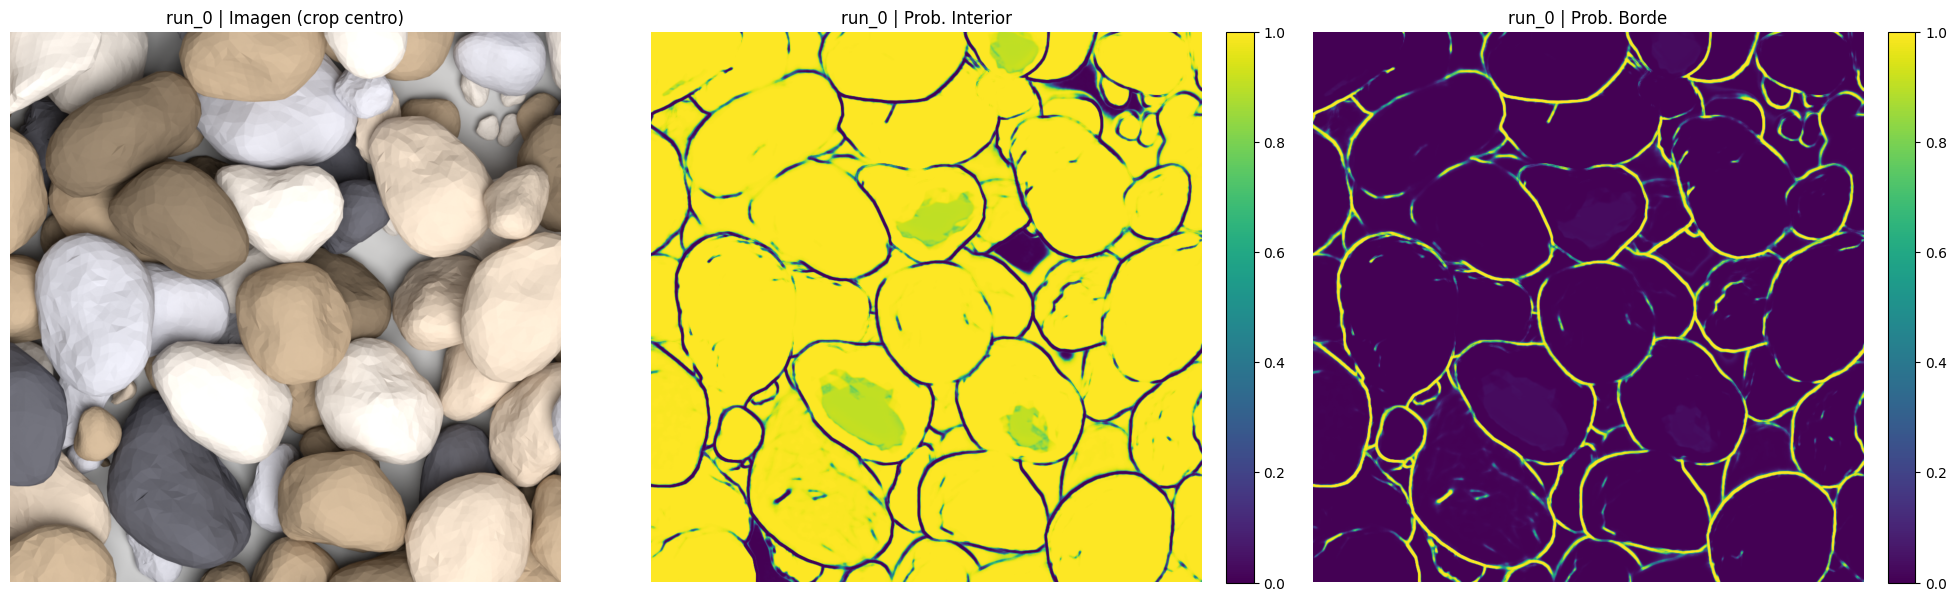

🧪 Debug extracción: {'fg_grow_frac': 0.8035924285650253, 'border_px_real': 6152072, 'border_mode': 'from_model', 'border_px_final': 8210463, 'fg_seed_frac': 0.7540364265441895, 'dist_max': 142.60157775878906, 'seeds_mode': 'dist_transform', 'n_seed_cc': 1588, 'labels_max': 1589, 'removed_small_labels': 27}
🧩 Partículas detectadas (IA): n=1561
📌 IA percentiles: D10=0.7108 mm | D50=1.1314 mm | D90=1.6210 mm
📌 GT percentiles: D10=0.7904 mm | D50=1.1569 mm | D90=1.5120 mm
📌 Error relativo: D10=10.06% | D50=2.20% | D90=7.21%
✅ CSV guardado: ./outputs\run_20260127_031124_ENSEMBLE\particles_ia_run0_ws.csv


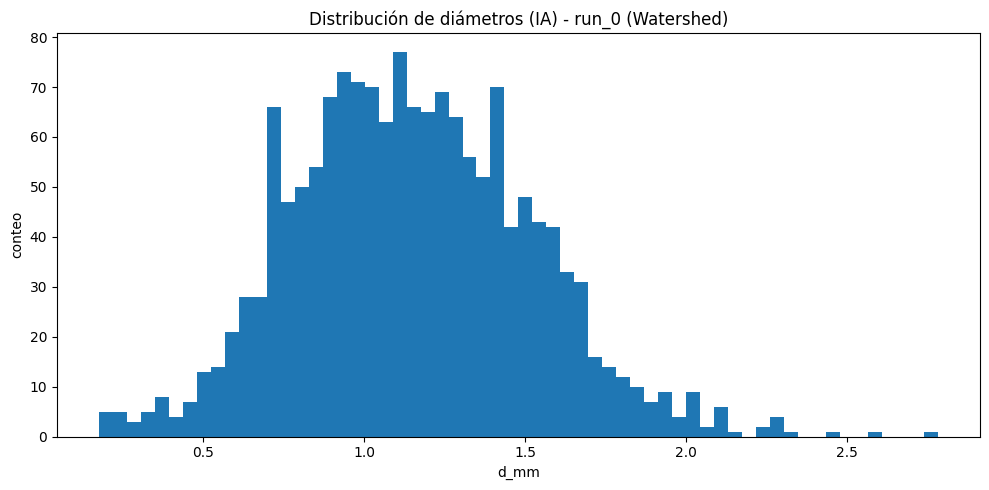

✅ Overlay guardado: ./outputs\run_20260127_031124_ENSEMBLE\overlay_contours_run0_ws.png


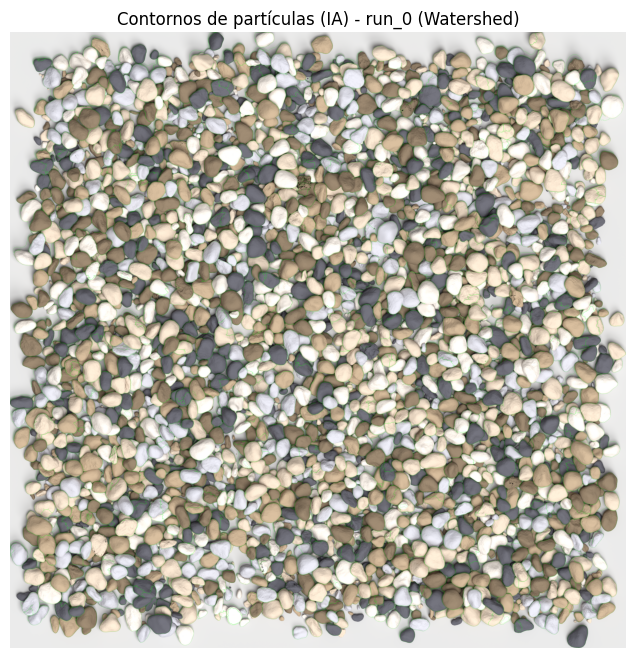

In [39]:
# ================================
# 6) EXTRACCIÓN ROBUSTA + DIAGNÓSTICO + REPORTE (UNIFICADO Y LIMPIO) [CORREGIDO]
# ================================
# Requisitos previos (de celdas anteriores):
#  - cfg, OUT_DIR, DEVICE definidos
#  - model cargado (o load_model(cfg.model_path) disponible)
#  - predict_sliding_window_probs(model, image_bgr, ...) definido (celda 3)
#  - meta_4000 definido (celda 5)
#  - GT (celda 4): idealmente gt_all y/o D10_GT, D50_GT, D90_GT disponibles
#
# Este bloque incluye TODO lo necesario para:
#  - leer mm_per_px desde meta JSON
#  - cargar/compute probs con cache
#  - guardar diagnóstico (crop centro)
#  - extraer partículas por watershed robusto
#  - reportar percentiles y error relativo vs GT (si está)
#  - guardar CSV + overlay

import os
import json
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import torch


# ---------------------------------------------------------
# Helpers generales
# ---------------------------------------------------------
def _ensure_probs_chw(probs: np.ndarray) -> np.ndarray:
    """Acepta probs CHW o HWC y retorna CHW float32."""
    p = np.asarray(probs)
    if p.ndim != 3:
        raise ValueError(f"probs debe ser 3D, llegó {p.shape}")
    if p.shape[0] in (2, 3):
        return p.astype(np.float32, copy=False)
    if p.shape[-1] in (2, 3):
        return p.transpose(2, 0, 1).astype(np.float32, copy=False)
    raise ValueError(f"Formato probs inesperado: {p.shape}")

def _odd_k(k: int, kmin: int = 3) -> int:
    k = int(k)
    if k < kmin:
        k = kmin
    if k % 2 == 0:
        k += 1
    return k

def _mm_per_px_from_meta(meta_path: str, view_width_mm_fallback: float, img_width_px: int) -> float:
    """Lee mm_per_px desde JSON de Blender. Fallback: view_width_mm/img_width_px."""
    mm_per_px = float(view_width_mm_fallback) / float(max(1, img_width_px))
    if meta_path and os.path.exists(meta_path):
        with open(meta_path, "r", encoding="utf-8") as f:
            m = json.load(f)
        vw = float(m.get("view_width_mm", view_width_mm_fallback))
        mm_per_px = float(m.get("mm_per_px", vw / float(max(1, img_width_px))))
        # Robustez: metadatos antiguos en micrones/px
        if mm_per_px > 0.1:
            mm_per_px = mm_per_px / 1000.0
    return float(mm_per_px)

def _as_chw_probs(probs: np.ndarray) -> np.ndarray:
    """Asegura probs en (C,H,W) con C=3."""
    p = np.asarray(probs)
    if p.ndim != 3:
        raise ValueError(f"probs debe ser 3D, llegó shape={p.shape}")
    if p.shape[0] == 3:
        return p.astype(np.float32, copy=False)
    if p.shape[-1] == 3:
        return p.transpose(2, 0, 1).astype(np.float32, copy=False)
    raise ValueError(f"No puedo inferir canales en probs. shape={p.shape}")

def _get_or_compute_probs(img_bgr: np.ndarray,
                          model: torch.nn.Module,
                          cache_path: str | None = None,
                          tile_size: int = 512,
                          overlap: float = 0.33) -> np.ndarray:
    """Carga probs desde cache si existe; si no, calcula con sliding-window y guarda."""
    if cache_path and os.path.exists(cache_path):
        probs = np.load(cache_path)
        probs = _as_chw_probs(probs)
        print(f"✅ Cache probs cargado: {cache_path}")
        return probs

    # Requiere que exista predict_sliding_window_probs (celda 3)
    if "predict_sliding_window_probs" not in globals():
        raise RuntimeError("No encuentro `predict_sliding_window_probs`. Ejecuta la celda 3 primero.")

    probs = predict_sliding_window_probs(model, img_bgr, tile_size=tile_size, overlap=overlap)  # (3,H,W)
    probs = _as_chw_probs(probs)

    if cache_path:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        np.save(cache_path, probs.astype(np.float32))
        print(f"✅ Cache probs guardado: {cache_path}")

    return probs

def _plot_center_crop_probs(img_bgr: np.ndarray,
                            probs_chw: np.ndarray,
                            crop_size: int = 1024,
                            save_path: str | None = None,
                            title_prefix: str = ""):
    """Guarda diagnóstico: imagen crop + prob interior + prob borde."""
    probs_chw = _as_chw_probs(probs_chw)
    H, W = img_bgr.shape[:2]
    hs = crop_size // 2
    cy, cx = H // 2, W // 2
    y0, y1 = max(0, cy - hs), min(H, cy + hs)
    x0, x1 = max(0, cx - hs), min(W, cx + hs)

    crop_bgr = img_bgr[y0:y1, x0:x1]
    crop_rgb = cv.cvtColor(crop_bgr, cv.COLOR_BGR2RGB)

    p_int = probs_chw[1, y0:y1, x0:x1]
    p_brd = probs_chw[2, y0:y1, x0:x1]

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    ax[0].imshow(crop_rgb)
    ax[0].set_title(f"{title_prefix} Imagen (crop centro)")
    ax[0].axis("off")

    im1 = ax[1].imshow(p_int, vmin=0, vmax=1)
    ax[1].set_title(f"{title_prefix} Prob. Interior")
    ax[1].axis("off")
    plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    im2 = ax[2].imshow(p_brd, vmin=0, vmax=1)
    ax[2].set_title(f"{title_prefix} Prob. Borde")
    ax[2].axis("off")
    plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Diagnóstico guardado: {save_path}")
    plt.show()


# ---------------------------------------------------------
# Watershed robusto (API NUEVA: fg_open_k / fg_close_k; NO usa k_open)
# ---------------------------------------------------------
def extract_particles_ws_full(
    image_bgr,
    probs_chw,
    mm_per_px,
    # thresholds
    interior_thr=0.15,
    grow_thr=None,
    bg_thr=0.55,                 # gate por background
    tau_border=0.25,             # default más alto (evita borde “encendido”)
    # morfología foreground
    fg_open_k=5,                 # open pequeño ayuda a ruido
    fg_close_k=0,                # por defecto NO cerrar en denso (evita fusión)
    # morfología borde
    border_open_k=3,
    border_dilate_it=1,          # no engordar demasiado
    border_erode_it=0,
    min_border_pixels=200,
    # seeds
    seed_open_k=3,
    dist_fg_frac=0.28,           # más seeds (menos fusión)
    # filtros
    min_area_px=500.0,
    # topografía
    topo_border_weight=0.65,     # borde como “ridge”
    return_labels=True,
    return_debug=True,
):
    probs = _ensure_probs_chw(probs_chw)
    C, H, W = probs.shape
    p_bg = probs[0]
    p_in = probs[1]
    p_bd = probs[2] if C == 3 else np.zeros((H, W), np.float32)

    dbg = {}

    # ----------------------------
    # (A) fg_grow con compuerta bg
    # ----------------------------
    if grow_thr is None:
        grow_thr = max(0.06, 0.80 * float(interior_thr))

    fg_grow = ((p_in > float(grow_thr)) & (p_bg < float(bg_thr))).astype(np.uint8)

    # argmax como gate (más estricto)
    argm = np.argmax(probs, axis=0)
    fg_grow = (fg_grow & (argm == 1).astype(np.uint8)).astype(np.uint8)

    # morfología: OPEN
    fg_open_k = _odd_k(fg_open_k, 3)
    fg_grow = cv.morphologyEx(fg_grow, cv.MORPH_OPEN, np.ones((fg_open_k, fg_open_k), np.uint8))

    # morfología: CLOSE opcional
    if fg_close_k and int(fg_close_k) > 0:
        fg_close_k = _odd_k(fg_close_k, 3)
        fg_grow = cv.morphologyEx(fg_grow, cv.MORPH_CLOSE, np.ones((fg_close_k, fg_close_k), np.uint8))

    dbg["fg_grow_frac"] = float(fg_grow.mean())

    # ----------------------------
    # (B) borde (real o sintético)
    # ----------------------------
    border = (p_bd > float(tau_border)).astype(np.uint8)
    dbg["border_px_real"] = int(border.sum())

    if int(border.sum()) < int(min_border_pixels):
        grad = cv.morphologyEx(fg_grow, cv.MORPH_GRADIENT, np.ones((3, 3), np.uint8))
        border = (grad > 0).astype(np.uint8)
        dbg["border_mode"] = "synthetic_gradient"
    else:
        dbg["border_mode"] = "from_model"

    if border_open_k and int(border_open_k) >= 3:
        border_open_k = _odd_k(border_open_k, 3)
        border = cv.morphologyEx(border, cv.MORPH_OPEN, np.ones((border_open_k, border_open_k), np.uint8))

    if border_dilate_it:
        border = cv.dilate(border, np.ones((3, 3), np.uint8), iterations=int(border_dilate_it))
    if border_erode_it:
        border = cv.erode(border, np.ones((3, 3), np.uint8), iterations=int(border_erode_it))

    dbg["border_px_final"] = int(border.sum())

    # ----------------------------
    # (C) seeds
    # ----------------------------
    fg_seed = (p_in > float(interior_thr)).astype(np.uint8)
    fg_seed = cv.subtract(fg_seed, border)

    if seed_open_k and int(seed_open_k) >= 3:
        seed_open_k = _odd_k(seed_open_k, 3)
        fg_seed = cv.morphologyEx(fg_seed, cv.MORPH_OPEN, np.ones((seed_open_k, seed_open_k), np.uint8))

    dbg["fg_seed_frac"] = float(fg_seed.mean())

    dist = cv.distanceTransform(fg_seed, cv.DIST_L2, 5)
    dist_max = float(dist.max())
    dbg["dist_max"] = dist_max

    if dist_max > 1e-6:
        seeds = (dist >= float(dist_fg_frac) * dist_max).astype(np.uint8)
        dbg["seeds_mode"] = "dist_transform"
    else:
        seeds = (fg_seed > 0).astype(np.uint8)
        dbg["seeds_mode"] = "fg_seed_fallback"

    if int(seeds.sum()) == 0:
        seeds = (fg_seed > 0).astype(np.uint8)
        dbg["seeds_mode"] = "fg_seed_fallback_2"

    n_cc, cc = cv.connectedComponents(seeds)
    dbg["n_seed_cc"] = int(n_cc - 1)

    if n_cc <= 1:
        empty_df = pd.DataFrame(columns=["label", "area_px", "d_mm", "solidity"])
        if return_labels:
            return (empty_df, np.ones((H, W), np.int32), dbg) if return_debug else (empty_df, np.ones((H, W), np.int32))
        return (empty_df, dbg) if return_debug else empty_df

    # ----------------------------
    # (D) topografía
    # ----------------------------
    topo = np.clip((1.0 - p_in) + float(topo_border_weight) * p_bd, 0.0, 1.0).astype(np.float32)
    topo8 = (topo * 255.0).astype(np.uint8)
    topo_bgr = cv.cvtColor(topo8, cv.COLOR_GRAY2BGR)

    markers = np.zeros((H, W), np.int32)
    markers[fg_grow == 0] = 1
    markers[cc > 0] = cc[cc > 0] + 1

    labels_ws = cv.watershed(topo_bgr, markers)
    dbg["labels_max"] = int(labels_ws.max())

    # ----------------------------
    # (E) medir + filtrar + limpiar
    # ----------------------------
    data = []
    removed_small = 0
    max_lbl = int(labels_ws.max())

    mm2_per_px2 = float(mm_per_px) ** 2
    mm_per_px_f = float(mm_per_px)

    for lbl in range(2, int(labels_ws.max()) + 1):
        m = ((labels_ws == lbl) & (fg_grow > 0)).astype(np.uint8)

        if float(m.sum()) < float(min_area_px):
            labels_ws[labels_ws == lbl] = 1
            removed_small += 1
            continue

        cnts, _ = cv.findContours(m, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        if not cnts:
            labels_ws[labels_ws == lbl] = 1
            removed_small += 1
            continue

        cnt = max(cnts, key=cv.contourArea)
        area_px = float(cv.contourArea(cnt))
        if area_px < float(min_area_px):
            labels_ws[labels_ws == lbl] = 1
            removed_small += 1
            continue

        # --- hull / solidity ---
        hull = cv.convexHull(cnt)
        area_hull = float(cv.contourArea(hull))
        solidity = float(area_px / area_hull) if area_hull > 1e-9 else 1.0

        # --- perímetro y métricas derivadas ---
        perim_px = float(cv.arcLength(cnt, True))
        perim_mm = perim_px * mm_per_px_f

        area_mm2 = area_px * mm2_per_px2

        # d_eq por área (ya lo usabas)
        d_mm = float(2.0 * np.sqrt(area_mm2 / np.pi))

        # diámetro hidráulico 2D: Dh = 4A/P
        dh_mm = float(4.0 * area_mm2 / (perim_mm + 1e-12))

        # circularidad: 4πA/P^2
        circularity = float(4.0 * np.pi * area_mm2 / ((perim_mm + 1e-12) ** 2))

        # aspect ratio (minAreaRect)
        (cx, cy), (w, h), ang = cv.minAreaRect(cnt)
        w = float(w); h = float(h)
        if w < 1e-9 or h < 1e-9:
            aspect_ratio = 1.0
            feret_max_mm = 0.0
            feret_min_mm = 0.0
        else:
            aspect_ratio = float(max(w, h) / (min(w, h) + 1e-12))
            feret_max_mm = float(max(w, h) * mm_per_px_f)
            feret_min_mm = float(min(w, h) * mm_per_px_f)

        # convexidad por perímetro (opcional, <=1 típicamente)
        perim_hull_px = float(cv.arcLength(hull, True))
        convexity = float(perim_hull_px / (perim_px + 1e-12))

        data.append({
            "label": int(lbl),
            "area_px": area_px,
            "area_mm2": area_mm2,
            "perim_mm": perim_mm,
            "d_mm": d_mm,
            "dh_mm": dh_mm,
            "solidity": solidity,
            "circularity": circularity,
            "aspect_ratio": aspect_ratio,
            "feret_max_mm": feret_max_mm,
            "feret_min_mm": feret_min_mm,
            "convexity": convexity,
        })

    dbg["removed_small_labels"] = int(removed_small)
    df = pd.DataFrame(data)

    if return_labels:
        return (df, labels_ws, dbg) if return_debug else (df, labels_ws)
    return (df, dbg) if return_debug else df


# =========================================================
# EJECUCIÓN: Diagnóstico + Extracción + Reporte (run_0)
# =========================================================
assert "cfg" in globals(), "Falta cfg"
assert "OUT_DIR" in globals(), "Falta OUT_DIR"
assert "DEVICE" in globals(), "Falta DEVICE"
assert "meta_4000" in globals(), "Primero ejecuta celda 5 (meta_4000)."

# --- obtener modelo ---
if "model" not in globals():
    if "load_model" in globals():
        model = load_model(cfg.model_path)
    else:
        raise RuntimeError("No encuentro `model` ni `load_model()`. Asegura que el modelo esté cargado.")
model.eval()

# --- escenario (solo ENSEMBLE/run_0) ---
IMG_PATH = os.path.join(cfg.ensemble_img_dir, "run_0.png")
META_PATH = os.path.join(cfg.ensemble_img_dir, "run_0.json")
assert os.path.exists(IMG_PATH), f"No existe IMG_PATH={IMG_PATH}"
assert os.path.exists(META_PATH), f"No existe META_PATH={META_PATH}"

img_bgr = cv.imread(IMG_PATH, cv.IMREAD_COLOR)
assert img_bgr is not None, f"No pude leer imagen: {IMG_PATH}"

# --- mm_per_px: preferir meta_4000 (celda 5) pero validar contra META_PATH ---
mm_per_px_meta = float(meta_4000.get("mm_per_px", 0.0))
mm_per_px_json = _mm_per_px_from_meta(
    META_PATH,
    float(meta_4000.get("view_width_mm", cfg.container_width_mm)),
    img_bgr.shape[1]
)

mm_per_px = mm_per_px_meta if mm_per_px_meta > 0 else mm_per_px_json
if abs(mm_per_px - mm_per_px_json) / max(mm_per_px_json, 1e-12) > 0.02:
    print(f"⚠️ mm_per_px(meta_4000) difiere de mm_per_px(json): {mm_per_px_meta:.9f} vs {mm_per_px_json:.9f}. Usando meta_4000.")
print(f"📏 mm_per_px = {mm_per_px:.9f} mm/px")

# --- probs cache ---
PROBS_CACHE = os.path.join(OUT_DIR, "probs_4000.npy")
probs = _get_or_compute_probs(
    img_bgr=img_bgr,
    model=model,
    cache_path=PROBS_CACHE,
    tile_size=512,
    overlap=0.33
)

# --- diagnóstico visual (crop centro) ---
diag_img_path = os.path.join(OUT_DIR, "diag_probs_center_run0.png")
_plot_center_crop_probs(
    img_bgr=img_bgr,
    probs_chw=probs,
    crop_size=1024,
    save_path=diag_img_path,
    title_prefix="run_0 |"
)

# --- parámetros desde meta_4000 (celda 5) ---
# Importante: esta versión NO usa k_open; usa fg_open_k / fg_close_k.
tau_border   = float(meta_4000["tau_border"])
interior_thr = float(meta_4000["interior_thr"])
min_area_px  = float(meta_4000["min_area_px"])

# Sugerencia para denso:
FG_OPEN_K  = 5
FG_CLOSE_K = 0

# Borde: partir desde meta_4000 pero moderar dilatación (4 era demasiado).
border_open_k    = int(meta_4000.get("border_open_k_full", 3))
border_dilate_it = 1
border_erode_it  = int(meta_4000.get("border_erode_it_full", 0))

# Seeds
DIST_FG_FRAC = 0.28  # rango típico 0.25–0.35

df, labels_ws, dbg = extract_particles_ws_full(
    image_bgr=img_bgr,
    probs_chw=probs,
    mm_per_px=mm_per_px,
    tau_border=tau_border,
    interior_thr=interior_thr,
    fg_open_k=FG_OPEN_K,
    fg_close_k=FG_CLOSE_K,
    border_open_k=border_open_k,
    border_dilate_it=border_dilate_it,
    border_erode_it=border_erode_it,
    min_area_px=min_area_px,
    dist_fg_frac=DIST_FG_FRAC,
    return_labels=True,
    return_debug=True,
)

print("🧪 Debug extracción:", dbg)
print(f"🧩 Partículas detectadas (IA): n={len(df)}")

if len(df) == 0:
    raise RuntimeError("No se detectaron partículas. Revisa probs / parámetros (tau/interior_thr/min_area/dist_fg_frac/bg_thr).")

# --- percentiles IA ---
d_ia = df["d_mm"].astype(float).values
p10, p50, p90 = np.percentile(d_ia, [10, 50, 90])
print(f"📌 IA percentiles: D10={p10:.4f} mm | D50={p50:.4f} mm | D90={p90:.4f} mm")

# --- percentiles GT (celda 4): soporta varias variantes (gt_all o D10_GT/...) ---
gt10 = gt50 = gt90 = None

if "gt_all" in globals() and isinstance(gt_all, np.ndarray) and gt_all.size > 0:
    gt10, gt50, gt90 = np.percentile(gt_all.astype(float), [10, 50, 90])
elif all(k in globals() for k in ("D10_GT", "D50_GT", "D90_GT")):
    gt10, gt50, gt90 = float(D10_GT), float(D50_GT), float(D90_GT)

if gt10 is not None:
    print(f"📌 GT percentiles: D10={gt10:.4f} mm | D50={gt50:.4f} mm | D90={gt90:.4f} mm")
    e10 = abs(p10 - gt10) / gt10 if gt10 > 0 else np.nan
    e50 = abs(p50 - gt50) / gt50 if gt50 > 0 else np.nan
    e90 = abs(p90 - gt90) / gt90 if gt90 > 0 else np.nan
    print(f"📌 Error relativo: D10={e10*100:.2f}% | D50={e50*100:.2f}% | D90={e90*100:.2f}%")
else:
    print("ℹ️ No encuentro GT (gt_all o D10_GT/D50_GT/D90_GT). Omitiendo comparación GT.")

# --- guardar CSV en OUT_DIR ---
csv_path = os.path.join(OUT_DIR, "particles_ia_run0_ws.csv")
df.to_csv(csv_path, index=False)
print(f"✅ CSV guardado: {csv_path}")

# --- histograma ---
plt.figure(figsize=(10, 5))
plt.hist(d_ia, bins=60)
plt.xlabel("d_mm")
plt.ylabel("conteo")
plt.title("Distribución de diámetros (IA) - run_0 (Watershed)")
plt.tight_layout()
plt.show()

# --- overlay de contornos (rápido) ---
overlay = img_bgr.copy()
for lbl in np.unique(labels_ws):
    if lbl <= 1:
        continue
    mask = (labels_ws == lbl).astype(np.uint8)
    cnts, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if cnts:
        cv.drawContours(overlay, cnts, -1, (0, 255, 0), 1)

overlay_path = os.path.join(OUT_DIR, "overlay_contours_run0_ws.png")
cv.imwrite(overlay_path, overlay)
print(f"✅ Overlay guardado: {overlay_path}")

plt.figure(figsize=(8, 8))
plt.imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
plt.title("Contornos de partículas (IA) - run_0 (Watershed)")
plt.axis("off")
plt.show()


In [43]:
# ================================
# 7) Extracción + métricas + (guardar labels) + morfología + ws (runs 0..4)
# ================================
import os, json
import numpy as np
import pandas as pd
import cv2 as cv
import math

RUN_IDS = [0, 1, 2, 3, 4]

# -----------------------------
# Meta render (run_i.json)
# -----------------------------
def load_render_meta(meta_path: str) -> dict:
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    if ("view_width_mm" not in meta) and ("mm_per_px" not in meta):
        raise ValueError(
            f"JSON meta inválido (no trae view_width_mm/mm_per_px). "
            f"Probable mezcla de carpetas. meta_path={meta_path} | keys={list(meta)[:20]}"
        )
    return meta

def get_mm_per_px_from_meta(meta: dict, width_px: int) -> float:
    view_width_mm = float(meta.get("view_width_mm", cfg.container_width_mm))
    mm_per_px = float(meta.get("mm_per_px", view_width_mm / float(width_px)))
    if mm_per_px > 0.1:  # robustez legacy
        mm_per_px /= 1000.0
    return float(mm_per_px)

# -----------------------------
# Probs cache (por run)
# -----------------------------
def _ensure_probs_chw(probs: np.ndarray) -> np.ndarray:
    p = np.asarray(probs)
    if p.ndim != 3:
        raise ValueError(f"probs debe ser 3D, llegó {p.shape}")
    if p.shape[0] in (2, 3):
        return p.astype(np.float32, copy=False)
    if p.shape[-1] in (2, 3):
        return p.transpose(2, 0, 1).astype(np.float32, copy=False)
    raise ValueError(f"Formato probs inesperado: {p.shape}")

def get_or_compute_probs_for_run(run_id: int, img_bgr: np.ndarray, model, tile_size=512, overlap=0.33) -> np.ndarray:
    cache_path = os.path.join(OUT_DIR, f"probs_run{run_id}.npy")
    if os.path.exists(cache_path):
        probs = np.load(cache_path)
        return _ensure_probs_chw(probs)

    if "predict_sliding_window_probs" in globals():
        probs = predict_sliding_window_probs(model, img_bgr, tile_size=tile_size, overlap=overlap)
    elif "predict_sliding_window_probs_overlap" in globals():
        probs = predict_sliding_window_probs_overlap(model, img_bgr, tile_size=tile_size, overlap=overlap, bgr_to_rgb=True)
    else:
        raise RuntimeError("No encuentro predict_sliding_window_probs ni predict_sliding_window_probs_overlap. Revisa celda 3.")

    probs = _ensure_probs_chw(probs)
    np.save(cache_path, probs.astype(np.float32))
    return probs

# -----------------------------
# GT por run (si está disponible)
# -----------------------------
def compute_gt_dmm_for_run(run_id: int, visible_frac: float = 0.45) -> np.ndarray:
    assert "load_items_from_inbounds" in globals(), "Falta load_items_from_inbounds()"
    assert "select_top_layer_items" in globals(), "Falta select_top_layer_items()"
    assert "compute_item_d_mm" in globals(), "Falta compute_item_d_mm()"

    inb_path = os.path.join(cfg.ensemble_json_dir, cfg.ensemble_gt_pattern.format(i=run_id))
    items = load_items_from_inbounds(inb_path)
    top = select_top_layer_items(items, visible_frac=visible_frac)

    d = np.array([compute_item_d_mm(it) for it in top], dtype=float)
    d = d[np.isfinite(d) & (d > 0)]
    return d

# =========================================================
# Morfología + ws
# =========================================================
RHO_W = 1000.0
RHO_S = 2650.0
NU    = 1.0e-6
G     = 9.81

def _safe_perimeter(bin_mask: np.ndarray) -> float:
    cnts, _ = cv.findContours(bin_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if not cnts:
        return 0.0
    return float(sum(cv.arcLength(c, True) for c in cnts))

def _safe_hull_area(bin_mask: np.ndarray) -> float:
    cnts, _ = cv.findContours(bin_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return 0.0
    hulls = [cv.convexHull(c) for c in cnts]
    return float(sum(cv.contourArea(h) for h in hulls))

def _fit_ellipse_axes(bin_mask: np.ndarray):
    cnts, _ = cv.findContours(bin_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    c = max(cnts, key=cv.contourArea)
    if len(c) < 5:
        return None
    (cx, cy), (MA, ma), angle = cv.fitEllipse(c)
    major = float(max(MA, ma))
    minor = float(min(MA, ma))
    if minor <= 0:
        return None
    return major, minor

def ws_soulsby(d_m: float, rho_s=RHO_S, rho=RHO_W, nu=NU, g=G) -> float:
    if d_m <= 0:
        return np.nan
    s = rho_s / rho
    Dstar = d_m * (((s - 1.0) * g) / (nu**2))**(1.0/3.0)
    return (nu / d_m) * (math.sqrt(10.36**2 + 1.049*(Dstar**3)) - 10.36)

def ws_dietrich(d_m: float, csf: float, P: float,
                rho_s=RHO_S, rho=RHO_W, nu=NU, g=G) -> float:
    if d_m <= 0:
        return np.nan
    Dstar = (((rho_s - rho) * g * (d_m**3)) / (rho * (nu**2)))**(1.0/3.0)
    if Dstar <= 0:
        return np.nan
    x = math.log10(Dstar)

    logW_s = (-3.76715 + 1.92944*x - 0.09815*(x**2) - 0.00575*(x**3) + 0.00056*(x**4))

    csf = float(np.clip(csf, 0.05, 0.99))
    logR2 = (-math.log10(1.0 - 0.85*csf)
             - ((1.0 - csf)**2.3)*math.tanh(x - 4.6)
             + 0.3*(0.5 - csf)*((1.0 - csf)**2)*x)

    logR3 = (0.65 - (csf/2.83)*math.tanh(x - 4.6)) * math.tanh(x - 1.9)

    logW = logW_s + logR2 + (logR3*(P - 1.0))
    Wstar = 10.0**(logW)

    ws = (Wstar * (rho_s - rho) * g * nu / rho)**(1.0/3.0)
    return ws

def morpho_table_from_labels(labels_ws: np.ndarray, mm_per_px: float, run_id: int,
                             P_default=3.5, csf_target_median=0.70):
    ids = np.unique(labels_ws)
    ids = ids[(ids > 1)]  # 0 y 1 = watershed fondo/borde

    # escala CSF proxy para que la mediana quede ~0.70 (robusto)
    tmp = []
    for lab in ids:
        m = (labels_ws == lab).astype(np.uint8) * 255
        axes = _fit_ellipse_axes(m)
        if axes is None:
            continue
        major, minor = axes
        AR = major / max(minor, 1e-6)
        csf2d = 1.0 / math.sqrt(max(AR, 1e-6))
        tmp.append(csf2d)

    scale = 1.0
    if len(tmp) >= 20:
        med = float(np.median(tmp))
        if med > 0:
            scale = csf_target_median / med

    px_to_mm = mm_per_px
    px_to_m  = mm_per_px * 1e-3

    rows = []
    for lab in ids:
        bin_mask = (labels_ws == lab).astype(np.uint8) * 255
        area_px = float(np.sum(bin_mask > 0))
        if area_px <= 0:
            continue

        per_px = _safe_perimeter(bin_mask)
        hull_area_px = _safe_hull_area(bin_mask)

        solidity = (area_px / hull_area_px) if hull_area_px > 0 else np.nan
        circularity = (4.0*math.pi*area_px / (per_px**2)) if per_px > 0 else np.nan

        axes = _fit_ellipse_axes(bin_mask)
        if axes is None:
            major_px, minor_px = np.nan, np.nan
            AR = np.nan
            csf_proxy = np.nan
        else:
            major_px, minor_px = axes
            AR = major_px / max(minor_px, 1e-6)
            csf_proxy = (1.0 / math.sqrt(max(AR, 1e-6))) * scale
            csf_proxy = float(np.clip(csf_proxy, 0.05, 0.99))

        d_eq_px = 2.0*math.sqrt(area_px / math.pi)
        d_eq_mm = d_eq_px * px_to_mm
        d_eq_m  = d_eq_px * px_to_m

        ws0 = ws_soulsby(d_eq_m)
        wsD = ws_dietrich(d_eq_m, csf=(csf_proxy if np.isfinite(csf_proxy) else 0.70), P=P_default)

        rows.append(dict(
            run=run_id,
            label=int(lab),
            area_px=area_px,
            per_px=per_px,
            solidity=solidity,
            circularity=circularity,
            major_px=major_px,
            minor_px=minor_px,
            aspect_ratio=AR,
            csf_proxy=csf_proxy,
            d_eq_mm=d_eq_mm,
            ws_soulsby_mps=ws0,
            ws_dietrich_mps=wsD,
            P_used=P_default
        ))
    return pd.DataFrame(rows)

# =========================================================
# EJECUCIÓN
# =========================================================
assert "cfg" in globals()
assert "OUT_DIR" in globals()
assert "meta_4000" in globals()
assert "model" in globals()
assert "extract_particles_ws_full" in globals()

rows = []
ia_all, gt_all = [], []

labels_by_run = {}
mmpp_by_run   = {}

tau_border   = float(meta_4000["tau_border"])
interior_thr = float(meta_4000["interior_thr"])
min_area_px  = float(meta_4000["min_area_px"])

# parámetros alineados a tu corrida buena
FG_OPEN_K       = 5
FG_CLOSE_K      = 0
BORDER_OPEN_K   = int(meta_4000.get("border_open_k_full", 3))
BORDER_DIL_IT   = 1
BORDER_ERODE_IT = int(meta_4000.get("border_erode_it_full", 0))
DIST_FG_FRAC    = 0.28
TOPO_BW         = 0.65
BG_THR          = 0.55

VISIBLE_FRAC_GT = 0.45
needed_gt = ["load_items_from_inbounds", "select_top_layer_items", "compute_item_d_mm"]
gt_enabled = all(n in globals() for n in needed_gt)

for rid in RUN_IDS:
    img_path  = os.path.join(cfg.ensemble_img_dir, f"run_{rid}.png")
    meta_path = os.path.join(cfg.ensemble_img_dir, f"run_{rid}.json")

    img_bgr = cv.imread(img_path, cv.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"No pude leer {img_path}")

    meta = load_render_meta(meta_path)
    mm_per_px = get_mm_per_px_from_meta(meta, width_px=img_bgr.shape[1])

    probs = get_or_compute_probs_for_run(rid, img_bgr, model, tile_size=512, overlap=0.33)

    df_ia, labels_ws, dbg = extract_particles_ws_full(
        image_bgr=img_bgr,
        probs_chw=probs,
        mm_per_px=mm_per_px,
        tau_border=tau_border,
        interior_thr=interior_thr,
        bg_thr=BG_THR,
        fg_open_k=FG_OPEN_K,
        fg_close_k=FG_CLOSE_K,
        border_open_k=BORDER_OPEN_K,
        border_dilate_it=BORDER_DIL_IT,
        border_erode_it=BORDER_ERODE_IT,
        min_area_px=min_area_px,
        dist_fg_frac=DIST_FG_FRAC,
        topo_border_weight=TOPO_BW,
        return_labels=True,
        return_debug=True,
    )

    # GUARDAR para celda 8 / morfología
    labels_by_run[rid] = labels_ws
    mmpp_by_run[rid]   = mm_per_px

    ia_d = df_ia["d_mm"].to_numpy(dtype=float) if len(df_ia) else np.array([], dtype=float)
    ia_d = ia_d[np.isfinite(ia_d) & (ia_d > 0)]

    gt_d = np.array([], dtype=float)
    if gt_enabled:
        gt_d = compute_gt_dmm_for_run(rid, visible_frac=VISIBLE_FRAC_GT)

    D10_IA, D50_IA, D90_IA = np.percentile(ia_d, [10,50,90]) if len(ia_d) else (np.nan, np.nan, np.nan)
    D10_GT, D50_GT, D90_GT = np.percentile(gt_d, [10,50,90]) if len(gt_d) else (np.nan, np.nan, np.nan)

    err10 = abs(D10_IA - D10_GT) / D10_GT * 100 if np.isfinite(D10_GT) and D10_GT > 0 else np.nan
    err50 = abs(D50_IA - D50_GT) / D50_GT * 100 if np.isfinite(D50_GT) and D50_GT > 0 else np.nan
    err90 = abs(D90_IA - D90_GT) / D90_GT * 100 if np.isfinite(D90_GT) and D90_GT > 0 else np.nan

    rows.append(dict(
        run=rid, mm_per_px=mm_per_px,
        n_ia=len(ia_d), n_gt=len(gt_d),
        D10_GT=D10_GT, D50_GT=D50_GT, D90_GT=D90_GT,
        D10_IA=D10_IA, D50_IA=D50_IA, D90_IA=D90_IA,
        err10=err10, err50=err50, err90=err90,
        fg_grow_frac=dbg.get("fg_grow_frac", np.nan),
        n_seed_cc=dbg.get("n_seed_cc", np.nan),
        removed_small=dbg.get("removed_small_labels", np.nan),
    ))

    ia_all.append(ia_d)
    if len(gt_d):
        gt_all.append(gt_d)

df_runs = pd.DataFrame(rows)
print(df_runs[["run","n_gt","n_ia","err10","err50","err90","fg_grow_frac","n_seed_cc","removed_small"]])

metrics_path = os.path.join(OUT_DIR, "metrics_runs_ws.csv")
df_runs.to_csv(metrics_path, index=False)
print("✅ Métricas guardadas:", metrics_path)

IA_ALL = np.concatenate(ia_all) if len(ia_all) else np.array([], dtype=float)
GT_ALL = np.concatenate(gt_all) if len(gt_all) else np.array([], dtype=float)

if len(IA_ALL):
    pd.DataFrame({"d_mm": IA_ALL}).to_csv(os.path.join(OUT_DIR, "particles_ia_ensemble_ws.csv"), index=False)
if len(GT_ALL):
    pd.DataFrame({"d_mm": GT_ALL}).to_csv(os.path.join(OUT_DIR, "particles_gt_ensemble_ws.csv"), index=False)

# -----------------------------
# Morfología + ws (usa labels_by_run/mmpp_by_run ya llenos)
# -----------------------------
df_morpho = pd.concat(
    [morpho_table_from_labels(labels_by_run[rid], mmpp_by_run[rid], run_id=rid, P_default=3.5) for rid in RUN_IDS],
    ignore_index=True
)
morpho_path = os.path.join(OUT_DIR, "particles_ia_morpho_ws.csv")
df_morpho.to_csv(morpho_path, index=False)
print("✅ Morfología+ws guardado:", morpho_path)

print(df_morpho[["d_eq_mm","solidity","aspect_ratio","circularity","ws_soulsby_mps","ws_dietrich_mps"]].describe())




   run  n_gt  n_ia      err10     err50     err90  fg_grow_frac  n_seed_cc  \
0    0  1800  1561   9.189462  2.198399  7.211262      0.803592       1588   
1    1  1800  1568  14.635239  4.466081  9.829238      0.791681       1603   
2    2  1800  1617  16.937553  4.226298  7.791541      0.803253       1647   
3    3  1800  1613  14.332471  2.978881  8.727686      0.811173       1662   
4    4  1800  1548  15.817283  1.876244  9.673525      0.804470       1579   

   removed_small  
0             27  
1             35  
2             30  
3             49  
4             31  
✅ Métricas guardadas: ./outputs\run_20260127_031124_ENSEMBLE\metrics_runs_ws.csv
✅ Morfología+ws guardado: ./outputs\run_20260127_031124_ENSEMBLE\particles_ia_morpho_ws.csv
           d_eq_mm     solidity  aspect_ratio  circularity  ws_soulsby_mps  \
count  7907.000000  7907.000000   7907.000000  7907.000000     7907.000000   
mean      1.146344     0.838731      1.572021     0.483953        0.127703   
std       

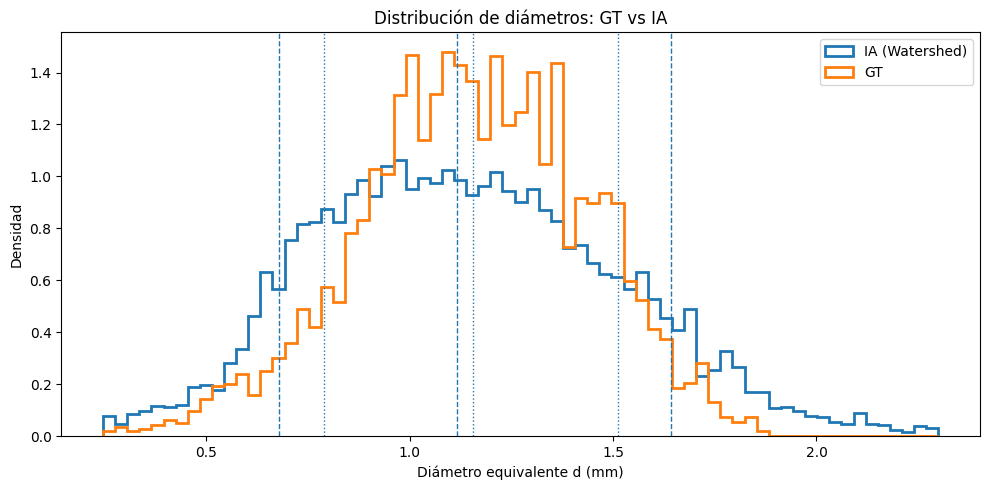

✅ Figura distribución guardada: ./outputs\run_20260127_031124_ENSEMBLE\fig_dist_diametros_GT_vs_IA.png
✅ Overlay etiquetas guardado: ./outputs\run_20260127_031124_ENSEMBLE\fig_overlay_labels_run0.png


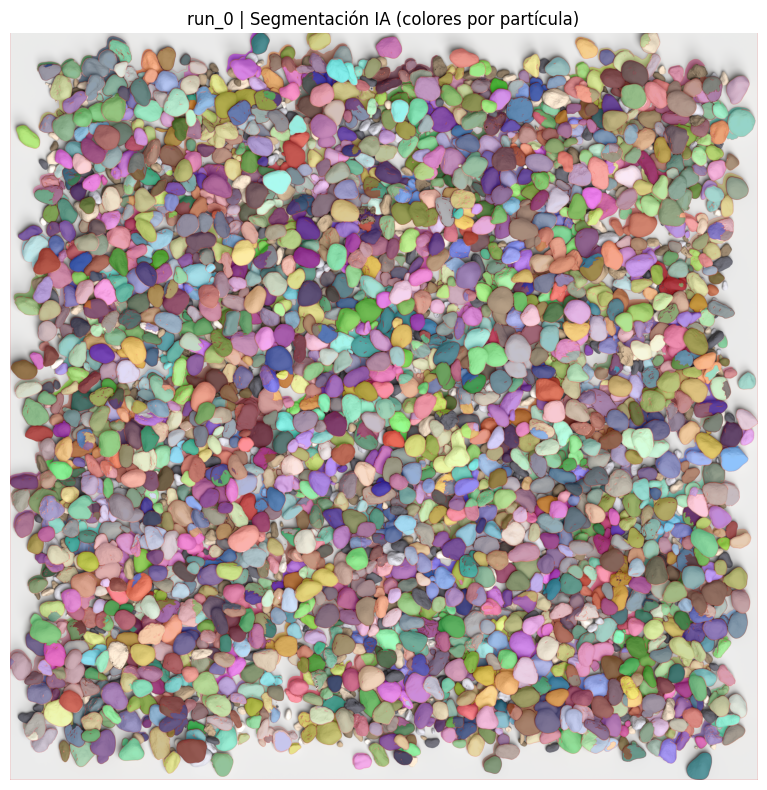

In [44]:
# ================================
# 8) FIGURAS PARA TESIS
#    (A) Distribución GT vs IA
#    (B) Overlay: máscara por partícula (colores) sobre render
# ================================
import os
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt

# -------------------------
# Helpers: cargar IA/GT
# -------------------------
def _load_diameters_from_csv(path: str) -> np.ndarray:
    df = pd.read_csv(path)
    # intenta columnas típicas
    for col in ["d_mm", "diameter_mm", "d"]:
        if col in df.columns:
            x = df[col].to_numpy(dtype=float)
            x = x[np.isfinite(x) & (x > 0)]
            return x
    raise ValueError(f"No encuentro columna de diámetros en {path}. Columnas: {list(df.columns)}")

# Preferir arrays en memoria (si existen); si no, leer CSV guardados por celda 7
IA_ALL_local = None
GT_ALL_local = None

if "IA_ALL" in globals() and isinstance(IA_ALL, np.ndarray) and IA_ALL.size > 0:
    IA_ALL_local = IA_ALL.astype(float)
else:
    ia_csv = os.path.join(OUT_DIR, "particles_ia_ensemble_ws.csv")
    if os.path.exists(ia_csv):
        IA_ALL_local = _load_diameters_from_csv(ia_csv)

if "GT_ALL" in globals() and isinstance(GT_ALL, np.ndarray) and GT_ALL.size > 0:
    GT_ALL_local = GT_ALL.astype(float)
else:
    gt_csv = os.path.join(OUT_DIR, "particles_gt_ensemble_ws.csv")
    if os.path.exists(gt_csv):
        GT_ALL_local = _load_diameters_from_csv(gt_csv)

assert IA_ALL_local is not None and IA_ALL_local.size > 0, "No pude obtener IA_ALL (ni en memoria ni en CSV)."
has_gt = (GT_ALL_local is not None and GT_ALL_local.size > 0)

# -------------------------
# (A) Figura: distribución GT vs IA
# -------------------------
# Bins comunes usando percentiles para evitar outliers raros
p_lo = np.percentile(IA_ALL_local, 0.5)
p_hi = np.percentile(IA_ALL_local, 99.5)
if has_gt:
    p_lo = min(p_lo, np.percentile(GT_ALL_local, 0.5))
    p_hi = max(p_hi, np.percentile(GT_ALL_local, 99.5))

bins = np.linspace(p_lo, p_hi, 70)

# Percentiles
D10_IA, D50_IA, D90_IA = np.percentile(IA_ALL_local, [10, 50, 90])
if has_gt:
    D10_GT, D50_GT, D90_GT = np.percentile(GT_ALL_local, [10, 50, 90])

plt.figure(figsize=(10, 5))
plt.hist(IA_ALL_local, bins=bins, density=True, histtype="step", linewidth=2, label="IA (Watershed)")
if has_gt:
    plt.hist(GT_ALL_local, bins=bins, density=True, histtype="step", linewidth=2, label="GT")

# Líneas percentiles
plt.axvline(D10_IA, linestyle="--", linewidth=1)
plt.axvline(D50_IA, linestyle="--", linewidth=1)
plt.axvline(D90_IA, linestyle="--", linewidth=1)
if has_gt:
    plt.axvline(D10_GT, linestyle=":", linewidth=1)
    plt.axvline(D50_GT, linestyle=":", linewidth=1)
    plt.axvline(D90_GT, linestyle=":", linewidth=1)

plt.xlabel("Diámetro equivalente d (mm)")
plt.ylabel("Densidad")
plt.title("Distribución de diámetros: GT vs IA")
plt.legend()
plt.tight_layout()

fig_dist_path = os.path.join(OUT_DIR, "fig_dist_diametros_GT_vs_IA.png")
plt.savefig(fig_dist_path, dpi=300)
plt.show()
print(f"✅ Figura distribución guardada: {fig_dist_path}")

# -------------------------
# (B) Figura: overlay con máscara por partícula (colores)
# -------------------------
# Elegir run para la figura del overlay
RID = 0  # cambia a 1..4 si prefieres otro render

# Cargar imagen y probs cacheados
img_path  = os.path.join(cfg.ensemble_img_dir, f"run_{RID}.png")
meta_path = os.path.join(cfg.ensemble_img_dir, f"run_{RID}.json")

img_bgr = cv.imread(img_path, cv.IMREAD_COLOR)
assert img_bgr is not None, f"No pude leer {img_path}"

# Cargar probs del cache (evita recomputar)
probs_cache = os.path.join(OUT_DIR, f"probs_run{RID}.npy")
if not os.path.exists(probs_cache):
    # fallback: si no existe cache por run, usa el de celda 6 si aplica
    probs_cache = os.path.join(OUT_DIR, "probs_4000.npy")
assert os.path.exists(probs_cache), f"No encuentro cache de probs: {probs_cache}"
probs = np.load(probs_cache)
probs = _ensure_probs_chw(probs)

# mm_per_px desde meta render (consistente con celda 7)
meta = load_render_meta(meta_path)
mm_per_px = get_mm_per_px_from_meta(meta, width_px=img_bgr.shape[1])

# Re-ejecutar extracción SOLO para obtener labels (rápido; probs ya están)
tau_border   = float(meta_4000["tau_border"])
interior_thr = float(meta_4000["interior_thr"])
min_area_px  = float(meta_4000["min_area_px"])

FG_OPEN_K   = 5
FG_CLOSE_K  = 0
BORDER_OPEN_K   = int(meta_4000.get("border_open_k_full", 3))
BORDER_DIL_IT   = 1
BORDER_ERODE_IT = int(meta_4000.get("border_erode_it_full", 0))
DIST_FG_FRAC    = 0.28
TOPO_BW         = 0.65
BG_THR          = 0.55

df_ia, labels_ws, dbg = extract_particles_ws_full(
    image_bgr=img_bgr,
    probs_chw=probs,
    mm_per_px=mm_per_px,
    tau_border=tau_border,
    interior_thr=interior_thr,
    bg_thr=BG_THR,
    fg_open_k=FG_OPEN_K,
    fg_close_k=FG_CLOSE_K,
    border_open_k=BORDER_OPEN_K,
    border_dilate_it=BORDER_DIL_IT,
    border_erode_it=BORDER_ERODE_IT,
    min_area_px=min_area_px,
    dist_fg_frac=DIST_FG_FRAC,
    topo_border_weight=TOPO_BW,
    return_labels=True,
    return_debug=True,
)

# Crear imagen color por etiqueta (cada partícula un color)
H, W = labels_ws.shape
max_lbl = int(labels_ws.max())
rng = np.random.default_rng(123)  # fijo para reproducibilidad (tesis)

# Mapa colores (BGR)
colors = np.zeros((max_lbl + 1, 3), dtype=np.uint8)
colors[0] = (0, 0, 0)
colors[1] = (0, 0, 0)
if max_lbl >= 2:
    colors[2:] = rng.integers(0, 256, size=(max_lbl - 1, 3), dtype=np.uint8)

color_img = np.zeros((H, W, 3), dtype=np.uint8)
mask_particles = labels_ws >= 2
color_img[mask_particles] = colors[labels_ws[mask_particles]]

# Contorno watershed (-1) si existe: marcarlo (rojo)
mask_boundary = labels_ws == -1
color_img[mask_boundary] = (0, 0, 255)

# Mezcla (solo sobre partículas, no sobre fondo)
alpha = 0.45
overlay = img_bgr.copy()
overlay[mask_particles] = (img_bgr[mask_particles] * (1 - alpha) + color_img[mask_particles] * alpha).astype(np.uint8)
overlay[mask_boundary] = (0, 0, 255)  # contorno visible

overlay_path = os.path.join(OUT_DIR, f"fig_overlay_labels_run{RID}.png")
cv.imwrite(overlay_path, overlay)
print(f"✅ Overlay etiquetas guardado: {overlay_path}")

plt.figure(figsize=(8, 8))
plt.imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
plt.title(f"run_{RID} | Segmentación IA (colores por partícula)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [45]:
# ================================
# 8) Morfología (2D) + ws físico–empírico (Soulsby + Dietrich)
# ================================
import numpy as np
import pandas as pd
import cv2 as cv
import math

# --- constantes físicas (ajusta si quieres) ---
RHO_W = 1000.0       # kg/m3
RHO_S = 2650.0       # kg/m3 (cuarzo)
NU    = 1.0e-6       # m2/s (agua ~20°C)
G     = 9.81         # m/s2

def _safe_perimeter(bin_mask: np.ndarray) -> float:
    cnts, _ = cv.findContours(bin_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if not cnts:
        return 0.0
    return float(sum(cv.arcLength(c, True) for c in cnts))

def _safe_hull_area(bin_mask: np.ndarray) -> float:
    cnts, _ = cv.findContours(bin_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return 0.0
    hulls = [cv.convexHull(c) for c in cnts]
    return float(sum(cv.contourArea(h) for h in hulls))

def _fit_ellipse_axes(bin_mask: np.ndarray):
    # retorna (major_px, minor_px) si posible; sino None
    cnts, _ = cv.findContours(bin_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    c = max(cnts, key=cv.contourArea)
    if len(c) < 5:
        return None
    (cx, cy), (MA, ma), angle = cv.fitEllipse(c)  # MA, ma son diámetros de ejes
    major = float(max(MA, ma))
    minor = float(min(MA, ma))
    if minor <= 0:
        return None
    return major, minor

# ---------- Soulsby (base) ----------
def ws_soulsby(d_m: float, rho_s=RHO_S, rho=RHO_W, nu=NU, g=G) -> float:
    # D* = d * [ ( (s-1) g ) / nu^2 ]^(1/3), con s = rho_s/rho
    s = rho_s / rho
    Dstar = d_m * (( (s - 1.0) * g ) / (nu**2))**(1.0/3.0)
    # ws = (nu/d) * ( sqrt(10.36^2 + 1.049 D*^3) - 10.36 ) 
    if d_m <= 0:
        return np.nan
    return (nu / d_m) * (math.sqrt(10.36**2 + 1.049*(Dstar**3)) - 10.36)

# ---------- Dietrich (con forma) ----------
def ws_dietrich(d_m: float, csf: float, P: float,
                rho_s=RHO_S, rho=RHO_W, nu=NU, g=G) -> float:
    # D* y W* según Dietrich
    if d_m <= 0:
        return np.nan
    Dstar = (((rho_s - rho) * g * (d_m**3)) / (rho * (nu**2)))**(1.0/3.0)
    if Dstar <= 0:
        return np.nan
    x = math.log10(Dstar)

    # log10(W*_sphere)
    logW_s = (-3.76715
              + 1.92944*x
              - 0.09815*(x**2)
              - 0.00575*(x**3)
              + 0.00056*(x**4))

    # log10(R2)  (shape correction)
    csf = float(np.clip(csf, 0.05, 0.99))
    logR2 = (-math.log10(1.0 - 0.85*csf)
             - ((1.0 - csf)**2.3)*math.tanh(x - 4.6)
             + 0.3*(0.5 - csf)*((1.0 - csf)**2)*x)

    # log10(R3) (roundness interaction)
    logR3 = (0.65 - (csf/2.83)*math.tanh(x - 4.6)) * math.tanh(x - 1.9)

    # log10(W*) final
    logW = logW_s + logR2 + (logR3*(P - 1.0))
    Wstar = 10.0**(logW)

    # W* = rho * ws^3 / ((rho_s - rho) g nu)  -> ws = [ W* (rho_s-rho) g nu / rho ]^(1/3)
    ws = (Wstar * (rho_s - rho) * g * nu / rho)**(1.0/3.0)
    return ws

def morpho_table_from_labels(labels_ws: np.ndarray, mm_per_px: float, run_id: int,
                             P_default=3.5, csf_target_median=0.70):
    H, W = labels_ws.shape[:2]
    rows = []
    ids = np.unique(labels_ws)
    ids = ids[ids != 0]

    # 1) primero recolecto AR para construir un CSF_proxy escalado (robusto)
    tmp = []
    for lab in ids:
        m = (labels_ws == lab).astype(np.uint8) * 255
        axes = _fit_ellipse_axes(m)
        if axes is None:
            continue
        major, minor = axes
        AR = major / max(minor, 1e-6)
        csf2d = 1.0 / math.sqrt(max(AR, 1e-6))  # ~ sqrt(b/a)  (proxy 2D)
        tmp.append(csf2d)

    scale = 1.0
    if len(tmp) >= 20:
        med = float(np.median(tmp))
        if med > 0:
            scale = csf_target_median / med

    # 2) métricas por partícula
    px_to_mm = mm_per_px
    px_to_m  = mm_per_px * 1e-3

    for lab in ids:
        bin_mask = (labels_ws == lab).astype(np.uint8) * 255
        area_px = float(np.sum(bin_mask > 0))
        if area_px <= 0:
            continue

        per_px = _safe_perimeter(bin_mask)
        hull_area_px = _safe_hull_area(bin_mask)

        solidity = (area_px / hull_area_px) if hull_area_px > 0 else np.nan
        circularity = (4.0*math.pi*area_px / (per_px**2)) if per_px > 0 else np.nan

        axes = _fit_ellipse_axes(bin_mask)
        if axes is None:
            major_px, minor_px = np.nan, np.nan
            AR = np.nan
            csf_proxy = np.nan
        else:
            major_px, minor_px = axes
            AR = major_px / max(minor_px, 1e-6)
            csf_proxy = (1.0 / math.sqrt(max(AR, 1e-6))) * scale
            csf_proxy = float(np.clip(csf_proxy, 0.05, 0.99))

        # d_eq desde área (2D): d = 2*sqrt(A/pi)
        d_eq_px = 2.0*math.sqrt(area_px / math.pi)
        d_eq_mm = d_eq_px * px_to_mm
        d_eq_m  = d_eq_px * px_to_m

        ws0 = ws_soulsby(d_eq_m)
        wsD = ws_dietrich(d_eq_m, csf=csf_proxy if np.isfinite(csf_proxy) else 0.70, P=P_default)

        Re0 = (ws0 * d_eq_m / NU) if np.isfinite(ws0) else np.nan
        ReD = (wsD * d_eq_m / NU) if np.isfinite(wsD) else np.nan

        rows.append(dict(
            run=run_id,
            label=int(lab),
            area_px=area_px,
            per_px=per_px,
            solidity=solidity,
            circularity=circularity,
            major_px=major_px,
            minor_px=minor_px,
            aspect_ratio=AR,
            csf_proxy=csf_proxy,
            d_eq_mm=d_eq_mm,
            ws_soulsby_mps=ws0,
            ws_dietrich_mps=wsD,
            Re_soulsby=Re0,
            Re_dietrich=ReD,
            P_used=P_default
        ))

    return pd.DataFrame(rows)

# -----------------------------
# EJEMPLO: correr para runs 0..4 usando tus labels_ws
# (aquí asumo que dentro de tu loop guardaste labels_ws por run)
# -----------------------------
# Si no los guardaste: vuelve a ejecutar la extracción y guarda labels_ws en un dict.

# labels_by_run = {rid: labels_ws_rid, ...}
# mmpp_by_run   = {rid: mm_per_px_rid, ...}

all_df = []
for rid in RUN_IDS:
    labels_ws = labels_by_run[rid]      # <- debes tenerlo
    mm_per_px = mmpp_by_run[rid]        # <- debes tenerlo

    dfm = morpho_table_from_labels(labels_ws, mm_per_px, run_id=rid, P_default=3.5)
    all_df.append(dfm)

df_morpho = pd.concat(all_df, ignore_index=True)
out_path = os.path.join(OUT_DIR, "particles_ia_morpho_ws.csv")
df_morpho.to_csv(out_path, index=False)
print("✅ Guardado:", out_path)

print(df_morpho[["run","d_eq_mm","solidity","aspect_ratio","ws_soulsby_mps","ws_dietrich_mps"]].describe())


✅ Guardado: ./outputs\run_20260127_031124_ENSEMBLE\particles_ia_morpho_ws.csv
               run      d_eq_mm     solidity  aspect_ratio  ws_soulsby_mps  \
count  7917.000000  7917.000000  7917.000000   7917.000000     7917.000000   
mean      2.002400     1.167894     0.837838      1.571313        0.128212   
std       1.405475     0.803989     0.128236      0.451890        0.031414   
min       0.000000     0.166719     0.019521      1.000000        0.019666   
25%       1.000000     0.871427     0.762614      1.275826        0.110332   
50%       2.000000     1.121876     0.863205      1.476706        0.129092   
75%       3.000000     1.398688     0.941256      1.745283        0.146879   
max       4.000000    29.168812     1.008545     11.339298        0.703403   

       ws_dietrich_mps  
count      7917.000000  
mean          0.007582  
std           0.007624  
min           0.001161  
25%           0.005306  
50%           0.007042  
75%           0.009108  
max           0.286

In [48]:
df_clean = df_morpho.copy()

q995 = df_clean["d_eq_mm"].quantile(0.995)

# filtros robustos
df_clean = df_clean[
    (df_clean["d_eq_mm"] > 0) &
    (df_clean["d_eq_mm"] <= q995) &
    (df_clean["aspect_ratio"] <= 6.0)
].copy()

print("Antes:", len(df_morpho), "Después:", len(df_clean))
print("max d_eq_mm antes:", df_morpho["d_eq_mm"].max(), "después:", df_clean["d_eq_mm"].max())
print("q99.5 usado:", q995)
out_clean = os.path.join(OUT_DIR, "particles_ia_morpho_ws_CLEAN.csv")
df_clean.to_csv(out_clean, index=False)
print("✅ Guardado:", out_clean)


Antes: 7917 Después: 7872
max d_eq_mm antes: 29.168811930477446 después: 2.3453110983076697
q99.5 usado: 2.3454002826698694
✅ Guardado: ./outputs\run_20260127_031124_ENSEMBLE\particles_ia_morpho_ws_CLEAN.csv
